In [ ]:
# ─────────────────────────────────────────────────────────────
#  Configuración inicial - Instalación de dependencias
# ─────────────────────────────────────────────────────────────
# !pip install plantuml requests ipython -q
# Ignore este código sólo se corre al inicio para conectar con plantuml y renderizar las imágenes dentro de este documento
# pero como puede darse cuenta al leer, las imágenes ya están renderizadas

import os
import tempfile
from pathlib import Path
from IPython.display import Image, display, Markdown, Code ##no se preocupe si da error codigo propio de jypyter, funciona

# ── Renderizador de diagramas PlantUML ──
try:
    from plantuml import PlantUML
    PLANTUML_SERVER = PlantUML(url='http://www.plantuml.com/plantuml/img/')
    _plantuml_available = True
except ImportError:
    _plantuml_available = False

def render_plantuml(plantuml_code, width=800):
    # Renderiza código PlantUML y muestra la imagen. Si no hay conexión al servidor, muestra el código fuente. #
    #==========================================================================================================#
    
    full_code = plantuml_code.strip()
    if not full_code.startswith('@startuml'):
        full_code = '@startuml\n' + full_code
    if not full_code.rstrip().endswith('@enduml'):
        full_code = full_code.rstrip() + '\n@enduml'

    if _plantuml_available:
        try:
            img_data = PLANTUML_SERVER.processes(full_code)
            display(Image(data=img_data, width=width))
            return
        except Exception:
            pass

    # Fallback: mostrar código fuente
    print('[WARN] No se pudo renderizar el diagrama (sin conexion al servidor PlantUML).')
    print('Código fuente:')
    print('```plantuml')
    print(full_code)
    print('```')

def render_plantuml_from_file(puml_path, width=800):
    #Lee un archivo .puml y renderiza el diagrama.#
    #=============================================#
    try:
        with open(puml_path, 'r', encoding='utf-8') as f:
            code = f.read()
        render_plantuml(code, width)
    except FileNotFoundError:
        print(f'Archivo no encontrado: {puml_path}')

print('Configuracion completada. Los diagramas PlantUML se renderizaran en linea.')


Configuracion completada. Los diagramas PlantUML se renderizaran en linea.


# 1. ¿Qué es un Caso de Uso?

Cuando un stakeholder se acerca y nos dice "quiero que el sistema haga tal cosa", no está pensando en funciones, módulos o algoritmos. Está pensando en un **objetivo concreto** que desea alcanzar. El concepto de Caso de Uso, introducido por Ivar Jacobson en los 80 y adoptado como pilar de UML, captura exactamente esa idea: *un caso de uso es una secuencia de acciones que un sistema ejecuta para producir un resultado observable de valor para un actor particular*.

Nótese que no hablamos de "funciones" sino de **secuencias de interacciones**. Una función es una operación atómica ("validar email"), mientras que un caso de uso es una historia completa ("Registrar Usuario"), con validaciones, alternativas, errores y un resultado de valor. Es una **narrativa de valor** que contextualiza cada acción técnica.

> **UML estándar vs. PlantUML:** En UML, un caso de uso se dibuja como una elipse con su nombre dentro. En PlantUML escribimos `(Nombre del Caso de Uso)` y la herramienta genera la elipse automáticamente. La notación UML es el estándar; PlantUML es una implementación textual que lo reproduce fielmente. Los conceptos que aprendan aquí son transferibles a cualquier herramienta UML.

En las próximas secciones iremos construyendo el modelo capa a capa: empezaremos por los actores (¿quién interactúa?), luego los casos de uso como objetivos (¿qué quiere cada actor?), después las relaciones entre ellos, la especificación detallada de cada flujo, y finalmente cómo organizar todo cuando el sistema crece.

___

# 2. Actores: Los que interactúan con el sistema

Si los casos de uso son las historias de valor que el sistema ofrece, los actores son los protagonistas (y antagonistas) de esas historias. Un actor no es simplemente "un usuario"; es un rol que una entidad externa —persona, sistema o dispositivo— desempeña en relación con nuestro software. Comprender a los actores en profundidad equivale a trazar el mapa social y técnico del sistema, y como Project Manager, ese mapa me indica *con quién debo hablar*, *qué dependencias externas existen* y *cómo organizar las pruebas de aceptación*.

## 2.1. Definición formal y clasificación

En UML, un **actor** es una entidad externa al sistema que interactúa con él a través del envío y recepción de mensajes. La palabra "externo" es clave: nunca modelamos como actor un componente interno de nuestro software. El actor está fuera de la frontera del sistema, y su comportamiento no está bajo nuestro control; solo podemos controlar cómo el sistema responde a sus estímulos.

La clasificación de actores que utilizo en mis proyectos va más allá del binomio primario/secundario, distingo al menos cuatro categorías que condicionan la planificación:

1. **Actores Humanos**: son las personas que usarán el sistema directamente para alcanzar un objetivo. Dentro de ellos, el *actor primario* es quien obtiene el valor central del caso de uso (ej. el Cliente en "Realizar Pedido"), mientras que un *actor humano de soporte* puede ser un Administrador que configura parámetros o un Agente de Soporte que atiende incidencias.

2. **Actores Sistema**: son otros sistemas informáticos con los que nuestro software debe integrarse. Se comunican mediante APIs, protocolos de red o archivos de intercambio, y son externos a nuestro control. Ejemplos típicos son Pasarelas de Pago, Servicios de Mensajería Instantánea, ERPs corporativos o Sistemas de Autenticación OAuth. La guía de PlantUML no distingue visualmente entre actores humanos y de sistema, pero en mis diagramas suelo utilizar nombres descriptivos y, si es necesario, estereotipos como `<<system>>` o `<<external service>>`.

3. **Actores Dispositivo**: sensores, actuadores, lectores de tarjetas, impresoras, básculas... cualquier hardware que envíe o reciba datos del sistema. En el Internet de las Cosas, estos actores son tan importantes como los humanos. Un sensor de temperatura que envía lecturas cada minuto es un actor que dispara casos de uso relacionados con la monitorización ambiental.

4. **El Tiempo como actor**: aunque no es frecuente mencionarlo como tal, ciertos casos de uso se disparan por eventos temporales (cada medianoche, cada primer día de mes). En PlantUML, estos casos de uso suelen iniciarse sin un actor visible, o puede modelarse un actor especial llamado "Temporizador" o "Scheduler".

## 2.2. Actores como roles, no como personas concretas

Un error que veo frecuentemente en ingenieros novatos es confundir *actor* con *persona específica*. "María" no es un actor; "Cliente" sí lo es. Un mismo individuo puede desempeñar varios roles (un empleado de la empresa puede ser a la vez Cliente Interno y Administrador), y varios individuos pueden encarnar el mismo rol (miles de Clientes interactúan con el sistema). El actor abstrae el conjunto de responsabilidades y expectativas que un rol tiene frente al sistema.

Esta distinción tiene consecuencias prácticas en la gestión del proyecto. Cuando planifico las pruebas de aceptación, no busco a "María" para que valide el sistema; busco representantes del *rol Cliente* que puedan verificar que los casos de uso cubren sus necesidades reales. Cuando diseño la interfaz, pienso en las características genéricas del rol (nivel de experiencia, frecuencia de uso, objetivos típicos), no en las preferencias personales de un usuario concreto.

En PlantUML, esta abstracción se refleja en la posibilidad de dar nombres descriptivos a los actores, e incluso alias para referenciarlos en relaciones sin repetir su nombre completo (guía, sección 1.2 y 1.4, páginas 2-4). Por ejemplo:



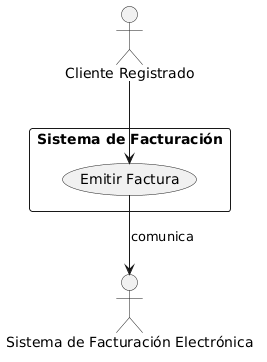

In [3]:
# Diagrama PlantUML
plantuml_code = '''@startuml
:Cliente Registrado: as Cliente
:Sistema de Facturación Electrónica: as SFE

rectangle "Sistema de Facturación" {
    (Emitir Factura)
}

Cliente --> (Emitir Factura)
(Emitir Factura) --> SFE : comunica
@enduml'''

render_plantuml(plantuml_code)



Aquí `Cliente` y `SFE` son alias que simplifican el código sin perder legibilidad. La guía también permite declarar actores con la palabra `actor` seguida de un nombre o de dos puntos, ofreciendo flexibilidad sintáctica.

## 2.3. Notación visual de actores en PlantUML: todas las variantes

La guía de PlantUML que estamos utilizando dedica las páginas 44 a 46 a la definición de actores, y nos muestra que existen múltiples maneras de declararlos y estilizarlos. Revisemos las más relevantes:

### 2.3.1. La elipse con nombre: el actor implícito

Si en una relación aparece un nombre que no ha sido declarado previamente como actor, PlantUML asume que se trata de un actor y lo dibuja automáticamente con la figura de palitos por defecto. Esto es útil para diagramas rápidos, aunque yo prefiero siempre declarar explícitamente los actores para tener control sobre sus alias y estilos.



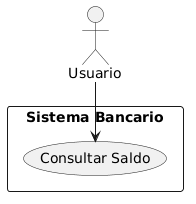

In [4]:
# Diagrama PlantUML
plantuml_code = '''@startuml
rectangle "Sistema Bancario" {
    (Consultar Saldo)
}
Usuario --> (Consultar Saldo)
@enduml'''

render_plantuml(plantuml_code)



En este ejemplo, `Usuario` se convierte automáticamente en un actor sin necesidad de declararlo antes.

### 2.3.2. Declaración explícita con dos puntos o con la palabra reservada `actor`

La sintaxis `:Nombre del Actor:` produce la representación de palitos, mientras que `actor Nombre` tiene el mismo efecto visual. Ambas permiten definir alias con `as`, lo que facilita referenciar al actor en múltiples relaciones.



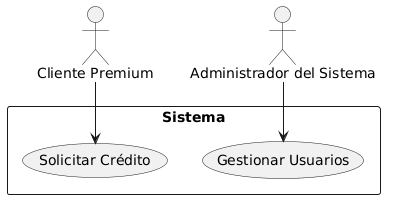

In [5]:
# Diagrama PlantUML
plantuml_code = '''@startuml
:Cliente Premium: as CP
actor "Administrador del Sistema" as Admin

rectangle "Sistema" {
    (Solicitar Crédito)
    (Gestionar Usuarios)
}

CP --> (Solicitar Crédito)
Admin --> (Gestionar Usuarios)
@enduml'''

render_plantuml(plantuml_code)



Observen cómo encerrar el nombre entre comillas permite incluir espacios y caracteres especiales. Esto es especialmente útil cuando el nombre del actor contiene tildes, eñes o cualquier carácter Unicode (guía, página 537). En proyectos internacionales, donde los actores pueden describirse en varios idiomas, esta flexibilidad es indispensable.

### 2.3.3. Cambiando el estilo visual del actor

Una funcionalidad que me resulta muy práctica para presentaciones ejecutivas es la posibilidad de cambiar la apariencia del actor mediante `skinparam actorStyle`. La guía (páginas 45-46) documenta tres estilos:

- **`stick` (por defecto)**: la clásica figura de palitos, adecuada para documentación técnica.
- **`awesome`**: una figura humana más detallada y estilizada, que resulta más profesional en presentaciones a stakeholders no técnicos.
- **`hollow`**: similar a `awesome` pero sin relleno, dibujando solo el contorno de la figura.



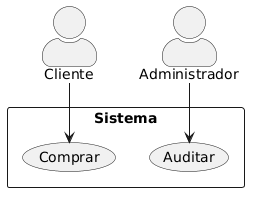

In [ ]:
# Diagrama PlantUML
plantuml_code = '''@startuml
skinparam actorStyle awesome
:Cliente: as C
:Administrador: as A

rectangle "Sistema" {
    (Comprar)
    (Auditar)
}

C --> (Comprar)
A --> (Auditar)
@enduml'''

render_plantuml(plantuml_code)
# NOTA: Si bien es cierto que el actor se puede cambiar
# nosotros usaremos exclusivamente el stickman para mantener uniformidad


Este simple cambio de estilo puede marcar la diferencia entre un diagrama que el cliente entiende de un vistazo y uno que percibe como "demasiado técnico". Como Project Manager, adapto el estilo según la audiencia: `stick` para el equipo de desarrollo, `awesome` para los patrocinadores del proyecto.

### 2.3.4. Actores de negocio con barra diagonal

La guía (páginas 54-55) introduce el concepto de *Business Actor*, que se representa añadiendo una barra diagonal `/` después del nombre del actor. Este actor de negocio pertenece al dominio del problema y no necesariamente interactúa con el sistema software, sino con los procesos de negocio en general. Es útil cuando estamos modelando el contexto organizacional más amplio.



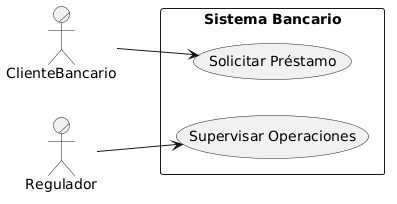

In [3]:
# Diagrama PlantUML
plantuml_code = '''@startuml
left to right direction

:ClienteBancario:/ as CB
:Regulador:/ as Reg

rectangle "Sistema Bancario" {
    (Solicitar Préstamo)
    (Supervisar Operaciones)
}

CB --> (Solicitar Préstamo)
Reg --> (Supervisar Operaciones)
@enduml'''

render_plantuml(plantuml_code)



La barra diagonal cruza el icono del actor, indicando visualmente que se trata de un rol de negocio. En fases tempranas del proyecto, cuando estamos definiendo el alcance funcional con los analistas de negocio, este tipo de actor me ayuda a distinguir entre quien usa el software y quien simplemente participa en el proceso global.

### 2.3.5. Múltiples líneas en el nombre del actor

En ocasiones, el nombre del actor necesita incluir información adicional (departamento, ubicación, etc.). La guía permite usar `\n` para insertar saltos de línea en el nombre. También se puede declarar el actor en varias líneas usando la palabra reservada `as` para asignar un alias corto al mismo tiempo (páginas 3-4).



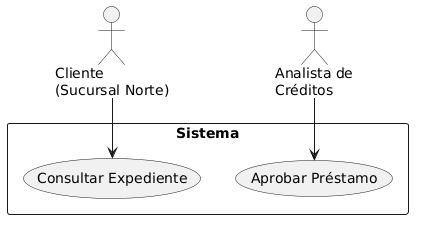

In [3]:
# Diagrama PlantUML
plantuml_code = '''@startuml
actor "Cliente\\n(Sucursal Norte)" as CN
:Analista de\\nCréditos: as AC

rectangle "Sistema" {
    (Consultar Expediente)
    (Aprobar Préstamo)
}

CN --> (Consultar Expediente)
AC --> (Aprobar Préstamo)
@enduml'''

render_plantuml(plantuml_code)



Esta capacidad de formato es crucial cuando el diagrama se incluye en documentos de especificación que requieren identificar con precisión a los actores sin saturar el gráfico con texto excesivamente largo en una sola línea.

### 2.3.6. Colores y estereotipos en actores

La guía muestra que podemos cambiar el color de fondo de un actor usando la notación `#color` después de su declaración (página 3). También podemos añadir estereotipos con `<< >>` para clasificar actores según su naturaleza (humano, sistema, dispositivo) o según su criticidad.



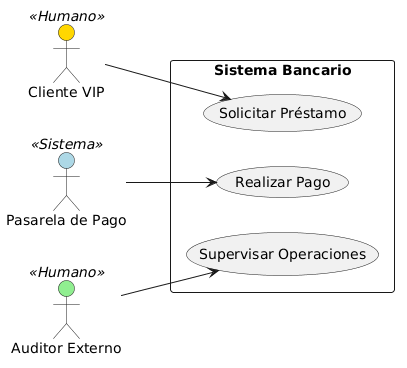

In [5]:
# Diagrama PlantUML
plantuml_code = '''@startuml
left to right direction

actor "Cliente VIP" as CVIP <<Humano>> #Gold
actor "Pasarela de Pago" as PP <<Sistema>> #LightBlue
actor "Auditor Externo" as AE <<Humano>> #LightGreen

rectangle "Sistema Bancario" {
    (Solicitar Préstamo)
    (Supervisar Operaciones)
    (Realizar Pago)
}

CVIP --> (Solicitar Préstamo)
PP --> (Realizar Pago)
AE --> (Supervisar Operaciones)
@enduml'''

render_plantuml(plantuml_code)


# 3. El Caso de Uso como Objetivo

Ya conocemos a los actores, los protagonistas de nuestras historias de software. Ahora toca entender dónde ocurren esas historias y qué forma tienen. En un diagrama UML de casos de uso, la escena se compone de tres elementos fundamentales: la **frontera del sistema** (el "escenario"), los **casos de uso** (los "actos" que el sistema sabe ejecutar) y los **actores** (quienes inician esos actos). En esta sección nos centramos en los dos primeros: el contenedor y la elipse.

## 3.1. La frontera del sistema: el rectángulo que delimita lo nuestro

Todo sistema de software tiene un límite. Ese límite separa lo que el sistema hace —y por tanto controlamos y desarrollamos— de lo que queda fuera. En UML, ese límite se dibuja como un **rectángulo** que contiene los casos de uso, y se etiqueta con el nombre del sistema.

> **UML estándar vs. PlantUML:** En UML estándar, la frontera del sistema se representa con un rectángulo («system boundary») que encierra todas las elipses. En PlantUML, podemos dibujarla con la palabra reservada `rectangle` o directamente con un `package`. Ambos producen un recuadro visual, pero el `rectangle` es semánticamente más fiel al concepto de frontera.

**Perspectiva PM:** La frontera del sistema es mi herramienta de negociación de alcance. Cada vez que un stakeholder pide una funcionalidad nueva, me pregunto: ¿está dentro o fuera del rectángulo? Si está fuera, es un actor o un sistema externo. Si está dentro, es un caso de uso que debemos estimar y planificar. Esta distinción evita el *scope creep* porque, visualmente, cualquier elipse nueva dentro del rectángulo es un compromiso de desarrollo.

**Perspectiva desarrollador:** La frontera me dice hasta dónde llega mi responsabilidad. Lo que está fuera del rectángulo no lo programo yo; son APIs de terceros, servicios externos o usuarios finales. Mi código termina donde termina el rectángulo.

Un ejemplo mínimo con `rectangle`:



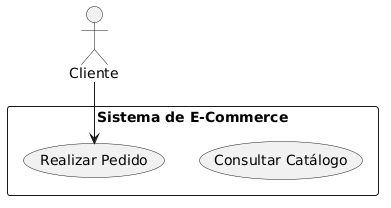

In [6]:
# Diagrama PlantUML
plantuml_code = '''@startuml
rectangle "Sistema de E-Commerce" {
  (Realizar Pedido)
  (Consultar Catálogo)
}
:Cliente: --> (Realizar Pedido)
@enduml'''

render_plantuml(plantuml_code)



La guía de PlantUML (páginas 46-47) utiliza el `rectangle` como contenedor del sistema, aunque también se pueden usar `package` o simplemente dejar las elipses sueltas sin frontera visible.

## 3.2. El caso de uso como elipse: el objetivo de valor

Si la frontera es el escenario, el **caso de uso** es la obra que se representa en él. En UML, un caso de uso se dibuja como una **elipse** (u óvalo) con su nombre en el interior. Esa elipse representa un objetivo completo que un actor puede alcanzar mediante la interacción con el sistema.

### 3.2.1. Sintaxis PlantUML básica

En PlantUML tenemos dos formas de declarar un caso de uso:

| Sintaxis | Ejemplo | Cuándo usarla |
|---|---|---|
| Paréntesis `(Nombre)` | `(Realizar Pedido)` | Rápida, para diagramas sencillos |
| `usecase "Nombre" as Alias` | `usecase "Realizar Pedido" as RP` | Cuando necesito alias o descripciones largas |

La primera forma es la más breve: escribes el nombre entre paréntesis y PlantUML genera la elipse. La segunda forma te da control adicional: puedes asignar un alias con `as` para referenciarlo en relaciones sin repetir el nombre, y puedes incluir saltos de línea con `\n` o descripciones largas con separadores visuales (`--`, `==`, `..`).



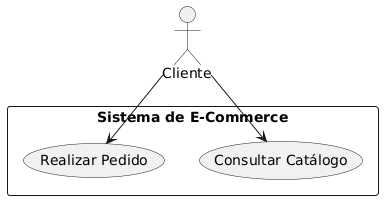

In [8]:
# Diagrama PlantUML
plantuml_code = '''@startuml
rectangle "Sistema de E-Commerce" {
  (Realizar Pedido)
  (Consultar Catálogo)
}

:Cliente: --> (Realizar Pedido)
:Cliente: --> (Consultar Catálogo)
@enduml'''

render_plantuml(plantuml_code)



> **UML estándar vs. PlantUML:** En UML estándar, la elipse es la *única* notación para un caso de uso. En PlantUML, los paréntesis `( )` son azúcar sintáctico que se transforma en una elipse al renderizar. Lo importante es que el concepto UML subyacente es idéntico.

### 3.2.2. Nomenclatura: verbo + sustantivo

Un caso de uso se nombra con un **verbo en infinitivo + sustantivo**: "Realizar Pedido", "Consultar Saldo", "Generar Informe". El verbo indica la acción que el sistema ejecuta; el sustantivo indica el objeto de esa acción. Esta convención no es caprichosa: garantiza que cualquier lector —técnico o de negocio— entienda de un vistazo qué valor produce el caso de uso.



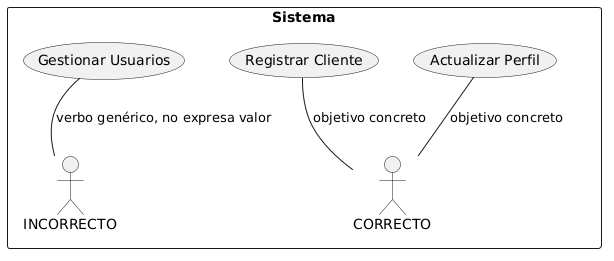

In [9]:
# Diagrama PlantUML
plantuml_code = '''@startuml
rectangle "Sistema" {
  (Gestionar Usuarios) -- INCORRECTO: verbo genérico, no expresa valor
  (Registrar Cliente)  -- CORRECTO: objetivo concreto
  (Actualizar Perfil)  -- CORRECTO: objetivo concreto
}
@enduml'''

render_plantuml(plantuml_code)



**Antipatrón CRUD:** Un error frecuente es crear casos de uso como "Gestionar X" o "Administrar Y", que terminan siendo contenedores de operaciones CRUD (Crear, Leer, Actualizar, Eliminar). "Gestionar Usuarios" no es un objetivo de valor; es un cajón donde metemos "Registrar Usuario", "Modificar Usuario", "Eliminar Usuario" y "Consultar Usuario". Cada una de esas operaciones es un caso de uso independiente porque responde a una necesidad distinta del actor y tiene flujos de error diferentes. Si ves "Gestionar" o "Administrar" en el nombre de un caso de uso, desconfía: probablemente escondes varios casos de uso bajo una misma elipse.

Volviendo al tema de nomenclatura: es mejor tener varias elipses con nombres precisos que una sola elipse ambigua que intente abarcarlo todo. La claridad del modelo se paga con más elipses, pero ese es un precio justo.

### 3.2.3. Los separadores visuales como documentación embebida

Cuando un caso de uso necesita incluir información adicional sin salir del diagrama —una descripción breve, precondiciones o un enlace a la especificación detallada—, PlantUML ofrece separadores visuales dentro de la declaración `usecase`:



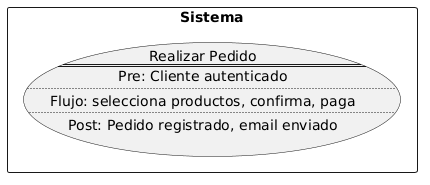

In [10]:
# Diagrama PlantUML
plantuml_code = '''@startuml
rectangle "Sistema" {
    usecase CU01 as "
      Realizar Pedido
      ==
      Pre: Cliente autenticado
      ..
      Flujo: selecciona productos, confirma, paga
      ..
      Post: Pedido registrado, email enviado
    "
}
@enduml'''

render_plantuml(plantuml_code)



Este enfoque es útil para documentación rápida, pero recuerda la regla de oro: el diagrama es un mapa, no una enciclopedia. El detalle completo pertenece a la especificación textual (sección 5).

## 3.3. Hacia una implementación concreta

Cuando un equipo de desarrollo recibe un diagrama de casos de uso, no solo ve elipses: ve **módulos de código**, **endpoints de API** y **pruebas que escribir**. Cada caso de uso debería poder rastrearse hasta una implementación concreta. Por ejemplo, "Realizar Pedido" (CU-01) podría traducirse en:



In [11]:
# app/use_cases/realizar_pedido.py
def ejecutar(cliente_id, productos, direccion_envio, metodo_pago):
    """Implementa el flujo básico del caso de uso CU-01."""
    carrito = crear_carrito(cliente_id)
    for prod in productos:
        if not validar_stock(prod.id, prod.cantidad):
            raise StockInsuficienteError(prod.id)
        carrito.agregar(prod)
    total = calcular_total(carrito, direccion_envio)
    pedido = crear_pedido(cliente_id, carrito, total)
    procesar_pago(pedido.id, metodo_pago, total)
    enviar_confirmacion(pedido.id, cliente_id)
    return pedido



Este fragmento —aunque simplificado— muestra cómo el flujo básico de 10 pasos visto en secciones anteriores se convierte en código real. Si el caso de uso incluía "Validar Stock" como relación `<<include>>`, esa validación estará en una función aparte que "Realizar Pedido" invoca, exactamente igual que en el diagrama.



In [12]:
# app/use_cases/validar_stock.py
def validar_stock(producto_id, cantidad):
    stock = obtener_stock(producto_id)
    return stock >= cantidad



## 3.4. Diagrama completo integrador

Cierro esta sección con un ejemplo que reúne los tres elementos —frontera del sistema, actores y casos de uso— en un diagrama autocontenido:



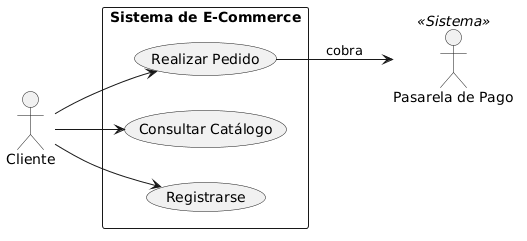

In [13]:
# Diagrama PlantUML
plantuml_code = '''@startuml
left to right direction
actor "Cliente" as C
actor "Pasarela de Pago" as Pay <<Sistema>>
rectangle "Sistema de E-Commerce" {
  (Realizar Pedido) as RP
  (Consultar Catálogo) as CC
  (Registrarse) as Reg
}
C --> RP
C --> CC
C --> Reg
RP --> Pay : cobra
@enduml'''

render_plantuml(plantuml_code)



Cada elemento en este diagrama tiene una razón de ser: los actores están fuera del rectángulo, los casos de uso dentro, y las líneas muestran quién inicia cada interacción. Este es el vocabulario visual mínimo que necesitas para cualquier diagrama de casos de uso. En la siguiente sección, cuando empecemos a conectar los casos de uso entre sí con relaciones, este vocabulario se enriquecerá, pero la estructura fundamental ya está aquí.

---

# 4. Relaciones entre Casos de Uso: Estructurando la funcionalidad

Hasta ahora hemos visto los casos de uso como unidades independientes de valor y a los actores como quienes los disparan. Pero en un sistema real, los casos de uso no son islas: se relacionan entre sí para compartir comportamiento, manejar opciones o especializarse. Comprender estas relaciones es fundamental para no terminar con un diagrama que parece un plato de espagueti, pero también para planificar correctamente el orden de implementación en el Gantt.

> **UML estándar vs. PlantUML:** UML define tres relaciones —inclusión, extensión y generalización— cada una con su semántica y notación específicas. PlantUML las reproduce fielmente mediante flechas con estereotipos (`<<include>>`, `<<extend>>`) o flechas de herencia (`<|--`). La guía que seguimos dedica las páginas 58-60 a esta sintaxis. Lo importante es que el significado UML es el mismo independientemente de la herramienta que uses.

## 4.1. ¿Por qué relacionamos casos de uso?

**Perspectiva PM:** Como Project Manager, tengo que responder constantemente a la pregunta "¿Cuánto nos tardamos en implementar todo esto?". Si veo que el caso de uso A repite exactamente los mismos pasos de validación que el caso de uso B, sé que no debo sumar dos esfuerzos completos, sino que puedo extraer la validación a un módulo compartido y planificarlo una sola vez. Las relaciones entre casos de uso me permiten justo eso: visualizar la reutilización, la opcionalidad y la especialización, y usar esa información para afinar la estimación y la secuencia de trabajo.

**Perspectiva analista:** Cuando estoy levantando requisitos y veo que un usuario dice "luego de hacer X, a veces necesito hacer Y" o "siempre que hago Z, primero debo verificar W", estoy escuchando relaciones entre casos de uso antes de que exista un diagrama. Mi trabajo es capturar esas dependencias en el modelo, no esperar a que el código las revele. Un buen modelo de relaciones me permite responder preguntas como "¿qué funcionalidades se rompen si cambiamos este módulo?" sin tocar una línea de código.

**Perspectiva desarrollador:** Cuando implemento, una relación `<<include>>` es una llamada a función o una inyección de dependencia. Un `<<extend>>` es un hook o un evento condicional. La generalización es herencia de clases o implementación de interfaces. Traducir estas relaciones a patrones de código concretos es mi responsabilidad diaria, y tenerlas claras en el diagrama me ahorra horas de leer especificaciones.

## 4.2. La Inclusión (`<<include>>`): El esqueleto compartido

### 4.2.1. Concepto y semántica UML

La inclusión es una relación estricta y obligatoria. Significa que el caso de uso *base* **siempre** ejecuta el caso de uso *incluido* en un punto concreto de su flujo. Es como una subrutina a nivel funcional: cuando el flujo básico de "Realizar Pedido" llega al paso "Validar que los productos tengan stock suficiente", ese paso no es opcional; es una condición necesaria para continuar. En lugar de escribir la validación dentro de "Realizar Pedido", la extraigo a un caso de uso separado "Validar Stock" y establezco una relación `<<include>>`.

El caso de uso incluido no conoce al caso de uso base; es autónomo y puede ser invocado por muchos casos de uso distintos. Típicamente, los casos de uso incluidos son de grano fino: "Autenticar Usuario", "Validar Formato de Email", "Verificar Límite de Crédito". Ninguno de ellos representa un objetivo completo de usuario por sí solo, sino un paso necesario dentro de un objetivo mayor.

### 4.2.2. Representación en PlantUML

En el manual de PlantUML que estamos estudiando, las relaciones entre casos de uso se dibujan con flechas y estereotipos (páginas 58-60). La inclusión se indica con la flecha `..>` o `-->` (dependiendo del estilo de línea) y el estereotipo `<<include>>`. La guía también permite usar la sintaxis `include` dentro de la definición de la flecha para mayor claridad.

Un ejemplo sencillo:



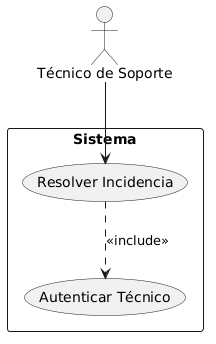

In [14]:
# Diagrama PlantUML
plantuml_code = '''@startuml
:Técnico de Soporte: as TS

rectangle "Sistema" {
    (Resolver Incidencia) as RI
    (Autenticar Técnico) as AT

    RI ..> AT : <<include>>
}
TS --> RI
@enduml'''

render_plantuml(plantuml_code)



Aquí, "Resolver Incidencia" incluye obligatoriamente "Autenticar Técnico". Observen que la flecha de inclusión apunta desde el caso de uso base (el que incluye) hacia el caso de uso incluido (el que es usado). Esta dirección es a veces confusa porque conceptualmente el flujo va del base al incluido, pero en UML la dependencia se dibuja hacia el elemento del que se depende.

### 4.2.3. Impacto en la gestión y el Gantt

**Perspectiva PM:** Desde mi rol de Project Manager, la inclusión tiene consecuencias directas en el cronograma:

- **Reutilización = ahorro de esfuerzo**: Si tres casos de uso incluyen "Validar Stock", estimo y planifico esa funcionalidad una sola vez. Mi Gantt tendrá una tarea "Implementar Validar Stock" antes o en paralelo a los casos de uso que la incluyen.
- **Precedencia técnica**: El caso de uso incluido debe estar operativo (al menos en una versión básica) antes de que los casos de uso base puedan probarse completamente. Esto me obliga a secuenciar tareas en el Gantt: no puedo probar "Realizar Pedido" hasta que "Validar Stock" esté implementado.
- **Pruebas de regresión**: Cada vez que modifico un caso de uso incluido, debo planificar tiempo adicional para probar todos los casos de uso base que dependen de él. Mi plan de proyecto debe contemplar ese esfuerzo de regresión como una tarea explícita o un buffer de contingencia.

**Perspectiva desarrollador:** En código, un `<<include>>` se traduce directamente en una función o método reutilizable. Si "Validar Stock" es un caso de uso incluido, escribiré una función `validar_stock(producto_id, cantidad)` que varios endpoints llamarán. El flujo básico del caso de uso base invoca esta función en un paso determinado, y si la validación falla, se dispara un flujo de excepción. Esta correspondencia uno a uno entre el diagrama y el código es lo que hace que los casos de uso sean una herramienta práctica, no solo teórica.

## 4.3. La Extensión (`<<extend>>`): El comportamiento opcional y controlado

### 4.3.1. Concepto y semántica UML

Si la inclusión es una relación de "siempre", la extensión es una relación de "a veces". En la extensión, un caso de uso *base* puede ejecutarse perfectamente sin el caso de uso *extendido*, pero bajo ciertas condiciones, el flujo del caso de uso base se interrumpe y se inserta el comportamiento del caso de uso extendido. Esto nos permite añadir funcionalidades sin modificar la estructura fundamental del caso de uso base.

La extensión está gobernada por un **punto de extensión** y una **condición de guarda**. El punto de extensión es un lugar concreto del flujo básico donde se puede insertar el comportamiento extra. La condición de guarda es una expresión booleana que debe cumplirse para que la extensión se active. Por ejemplo, en "Realizar Pedido", el flujo básico incluye el paso "Determinar costo de envío". Podemos definir un punto de extensión en ese paso, y un caso de uso extendido "Aplicar Envío Gratuito" con la condición de guarda "si el cliente es VIP y el pedido supera 100 euros".

El caso de uso extendido conoce al caso de uso base (sabe en qué punto de extensión se inserta), pero el caso de uso base no conoce al extendido. El base sigue siendo funcional incluso si el extendido nunca se activa.

### 4.3.2. Representación en PlantUML

La extensión se dibuja con una flecha `..>` o `-->` que apunta desde el caso de uso extendido hacia el caso de uso base (dirección opuesta a la inclusión), con el estereotipo `<<extend>>`. También se puede especificar el punto de extensión y la condición de guarda como una nota unida a la flecha.



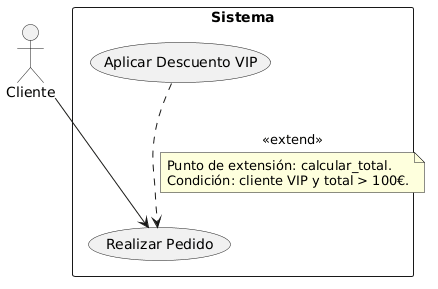

In [15]:
# Diagrama PlantUML
plantuml_code = '''@startuml
:Cliente: as C

rectangle "Sistema" {
    (Realizar Pedido) as RP
    (Aplicar Descuento VIP) as ADV

    ADV ..> RP : <<extend>>
    note on link : Punto de extensión: calcular_total.\\nCondición: cliente VIP y total > 100€.
}

C --> RP
@enduml'''

render_plantuml(plantuml_code)



La guía de PlantUML no dedica una sección exclusiva a la extensión, pero todas las relaciones entre casos de uso se manejan con la notación de flechas y estereotipos que vimos en el apartado anterior (páginas 58 y siguientes). La clave es que la punta de la flecha apunta al caso de uso base, y el estereotipo `<<extend>>` se coloca sobre la línea, generalmente entre `<<` y `>>`.

## 4.4. La Generalización: Cuando un caso de uso es una versión especializada de otro

### 4.4.1. Concepto y semántica UML

La generalización entre casos de uso funciona de forma análoga a la herencia en programación orientada a objetos. Un caso de uso *hijo* hereda el comportamiento del caso de uso *padre* y puede sobrescribir o extender partes de su flujo. El hijo representa una variante más concreta del objetivo del padre.

Un ejemplo clásico es la generalización de "Pago" en "Pago con Tarjeta", "Pago con PayPal" y "Pago contra Reembolso". Todos comparten la estructura general del pago (verificar fondos, registrar transacción, emitir comprobante), pero cada uno tiene pasos específicos (conectar con pasarela bancaria, redirigir a PayPal, marcar como pago pendiente). El caso de uso padre puede ser abstracto (no se ejecuta directamente) y los hijos concretos son los que realmente se invocan.

La relación de generalización se representa con una flecha de punta hueca (herencia UML estándar) que apunta desde el caso de uso hijo hacia el caso de uso padre.

### 4.4.2. Representación en PlantUML

La guía muestra que PlantUML soporta la notación de herencia con `<|--` (página 58). En el contexto de casos de uso, la sintaxis es similar a la de clases pero con los elementos adecuados:



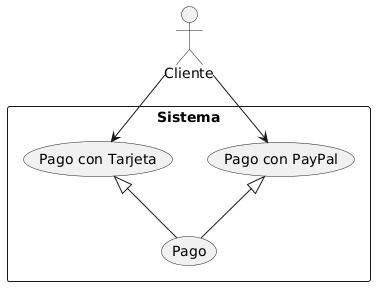

In [16]:
# Diagrama PlantUML
plantuml_code = '''@startuml
:Cliente: as C

rectangle "Sistema" {
    (Pago) as Pago
    (Pago con Tarjeta) as PT
    (Pago con PayPal) as PP

    PT <|-- Pago
    PP <|-- Pago
}

C --> PT
C --> PP
@enduml'''

render_plantuml(plantuml_code)



También es válido usar `usecase Pago as P` y luego conectar con `PT <|-- P`. La notación de PlantUML es flexible y soporta tanto la palabra reservada `usecase` como los paréntesis para definir casos de uso.

### 4.4.3. Impacto en la gestión y el Gantt

La generalización tiene implicaciones importantes para la planificación:

**Perspectiva PM:**
- **Implementación incremental**: Si defino "Pago" como un caso de uso abstracto, sé que tengo que implementar al menos un hijo concreto para que el sistema funcione. Luego puedo añadir los otros hijos en iteraciones sucesivas. Mi Gantt reflejará esta estrategia: primero "Pago con Tarjeta", luego "Pago con PayPal", luego "Pago contra Reembolso".
- **Reutilización del flujo básico**: El esfuerzo de implementar el flujo común del padre se contabiliza una sola vez. Los hijos solo añaden el esfuerzo de las personalizaciones. Esto me permite dar estimaciones más precisas a los stakeholders: "Implementar Pago base: 10 días. Añadir variante PayPal: 4 días adicionales. Añadir variante contra reembolso: 3 días adicionales".
- **Pruebas jerárquicas**: Los escenarios de prueba del padre deben pasar con cada hijo. Mi plan de pruebas incluirá la verificación de que los hijos no rompen el comportamiento heredado, lo que añade esfuerzo de pruebas de regresión.

**Perspectiva desarrollador:** En código, la generalización se traduce en herencia de clases (si usamos POO) o en implementación de interfaces. El caso de uso padre define el contrato y la lógica común; cada hijo sobrescribe los métodos que varían. Por ejemplo:



In [17]:
from abc import ABC, abstractmethod

class Pago(ABC):
    def ejecutar(self, monto):
        self.verificar_fondos(monto)
        self.registrar_transaccion(monto)
        self.emitir_comprobante()

    @abstractmethod
    def verificar_fondos(self, monto): ...

class PagoTarjeta(Pago):
    def verificar_fondos(self, monto):
        # conectar con pasarela bancaria
        ...

class PagoPayPal(Pago):
    def verificar_fondos(self, monto):
        # redirigir a PayPal
        ...



Este patrón asegura que cualquier nuevo método de pago que aparezca en el futuro herede automáticamente el flujo básico, reduciendo el riesgo de omitir pasos críticos.

## 4.5. Elección estratégica de relaciones

Un diagrama de casos de uso mal diseñado puede volverse inmantenible si se abusa de las relaciones. Comparto algunas reglas que aplico en mis proyectos:

**Perspectiva analista:**
- **Inclusión**: úsala cuando un comportamiento se repite literalmente en varios casos de uso y no tiene sentido por sí mismo como objetivo de usuario. Si ves que un mismo paso aparece copiado y pegado en tres especificaciones textuales, es candidato a inclusión.
- **Extensión**: úsala con moderación. Si tienes más de dos o tres extensiones en un mismo caso de uso base, considera si no es mejor replantear el base o crear generalizaciones. La extensión es ideal para comportamientos que son claramente opcionales o que corresponden a versiones futuras del sistema.
- **Generalización**: úsala cuando hay una clara relación "es-un" entre casos de uso, es decir, cuando un caso de uso es una forma particular de otro más genérico. No la uses solo porque dos casos de uso comparten algunos pasos; en esos casos, la inclusión es más adecuada.

**Perspectiva desarrollador:** Las relaciones no son solo decoración del diagrama; cada una tiene un costo de implementación y mantenimiento. Un `<<include>>` mal puesto crea un acoplamiento innecesario entre módulos. Un `<<extend>>` abusivo convierte el código en un laberinto de condicionales. Una generalización forzada produce jerarquías de clases que nadie entiende. Antes de añadir una relación, pregúntate: ¿esto simplifica o complica mi código?

**Perspectiva PM:** Cada relación que añado incrementa la complejidad de la planificación, pero también la claridad sobre qué depende de qué. Un diagrama sin relaciones puede ocultar dependencias que luego explotan durante el desarrollo. Un diagrama con demasiadas relaciones puede paralizar al equipo con una maraña de interdependencias. Como siempre, el equilibrio es la clave, y ese equilibrio se logra pensando en términos de valor entregado y esfuerzo de implementación.

## 4.6. Relaciones entre actores y casos de uso: la asociación

Aunque el foco de esta sección son las relaciones entre casos de uso, no quiero dejar de mencionar que la relación más básica del diagrama es la **asociación** entre un actor y un caso de uso. Es simplemente una línea que comunica el actor con el caso de uso que dispara o del que recibe valor. En PlantUML, como vimos en la sección anterior, se dibuja con `-->`.

La asociación puede tener multiplicidad, aunque rara vez se muestra en el diagrama para no sobrecargarlo. Por ejemplo, un Cliente puede ejecutar "Realizar Pedido" muchas veces, pero un Administrador que "Aprueba Pedidos" puede estar asociado a múltiples instancias simultáneas. La multiplicidad se especifica en la documentación textual y puede influir en el dimensionamiento de recursos (¿cuántos pedidos simultáneos debe soportar el sistema?), lo que a su vez impacta en las tareas de pruebas de carga que planifico en el Gantt.

En PlantUML, la asociación puede decorarse con etiquetas que aclaren la intención:



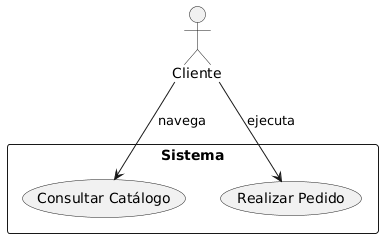

In [18]:
# Diagrama PlantUML
plantuml_code = '''@startuml
:Cliente: as C

rectangle "Sistema" {
    (Consultar Catálogo) as CC
    (Realizar Pedido) as RP
}

C --> CC : navega
C --> RP : ejecuta
@enduml'''

render_plantuml(plantuml_code)



Estas etiquetas ayudan a lectores no técnicos a entender el sentido de la interacción, aunque en UML puro la línea de asociación no lleva nombre. Como PM, las incluyo cuando el diagrama se va a presentar a un comité de dirección que no está familiarizado con la notación.

## 4.7. Resumen visual

Para cerrar, aquí tienes una referencia rápida de las tres relaciones con su sintaxis PlantUML:

| Relación | Semántica | Sintaxis PlantUML | Dirección de la flecha |
|---|---|---|---|
| Inclusión (`<<include>>`) | El caso de uso base *siempre* ejecuta el incluido | `Base ..> Incluido : <<include>>` | Del base al incluido |
| Extensión (`<<extend>>`) | El caso de uso base *a veces* ejecuta el extendido | `Extendido ..> Base : <<extend>>` | Del extendido al base |
| Generalización | El hijo *es un tipo de* padre | `Hijo <|-- Padre` | Del hijo al padre |

Un truco mnemotécnico: en la inclusión, la flecha **apunta hacia el que se usa** (el incluido). En la extensión, la flecha **apunta hacia el que se extiende** (el base). Son direcciones opuestas, así que si dudas, piensa en quién necesita a quién.

Con esto cubrimos las tres relaciones fundamentales entre casos de uso. En la próxima sección abordaremos la especificación textual detallada, que es donde realmente se juega el éxito del análisis de casos de uso. El diagrama es el mapa, pero la especificación es el territorio, y un Project Manager debe conocer ambos para guiar al equipo hacia la entrega exitosa del proyecto.

# 5. La Especificación Textual del Caso de Uso

Si el diagrama es la cartografía del sistema, la especificación textual es el relato detallado de cada viaje que un actor emprende con él. Los óvalos y las líneas nos muestran *qué* funcionalidades existen y *quién* puede ejecutarlas, pero callan sobre el *cómo* se desarrolla la interacción, *qué* reglas de negocio la gobiernan y *qué* sucede cuando algo no sale según lo previsto. Como ingenieros de software, no podemos construir un sistema a partir de simples elipses; necesitamos la narrativa completa, y esa narrativa se plasma en la especificación textual de casos de uso.

PlantUML nos permite anclar esta especificación al diagrama mediante notas, descripciones enriquecidas y enlaces, pero el artefacto principal sigue siendo un documento estructurado que merece tanta atención como el propio código fuente. A continuación, desglosaré la anatomía de una especificación profesional, su vinculación con la notación PlantUML y las prácticas que garantizan su utilidad durante todo el ciclo de vida del software.

> **UML estándar vs. PlantUML:** La especificación textual no es parte del estándar UML; UML solo define la notación gráfica (elipses, actores, relaciones). La plantilla que presentamos aquí es una práctica de la ingeniería de software que complementa el diagrama. PlantUML ayuda a enlazar ambas mediante notas e hipervínculos, como veremos en 5.3.

## 5.1. El vacío que el diagrama no puede llenar

Pensemos en un caso de uso tan común como "Realizar Pedido". En el diagrama, es un óvalo conectado al actor "Cliente". Pero un desarrollador que recibe únicamente ese gráfico se enfrenta a un mar de preguntas sin respuesta: ¿el cliente debe estar autenticado? ¿qué datos se solicitan? ¿cómo se calculan los impuestos? ¿qué alternativas de pago existen? ¿qué errores pueden ocurrir y cómo se comunica cada uno al usuario?

La especificación textual responde a cada una de estas cuestiones de forma inequívoca. Transforma una idea abstracta en una guía de implementación y validación. Es, en esencia, un contrato entre los interesados (que expresan la necesidad de negocio) y el equipo de desarrollo (que la materializa). Su ausencia es fuente de ambigüedad, retrabajo y, en última instancia, insatisfacción del cliente.

## 5.2. Estructura de una especificación de caso de uso de nivel profesional

A lo largo de mi experiencia, he consolidado una plantilla que captura todos los aspectos relevantes de un caso de uso sin caer en la burocracia. La siguiente tabla resume los componentes esenciales:

| Componente | Obligatorio | Describe |
|---|---|---|
| Identificación | Sí | Código, nombre, actores, propósito, prioridad |
| Precondiciones | Sí | Estado necesario antes de ejecutar |
| Flujo básico | Sí | Secuencia ideal paso a paso |
| Flujos alternativos | No | Variantes que también llevan al éxito |
| Flujos de excepción | Sí | Situaciones de error y cómo se manejan |
| Postcondiciones | Sí | Estado del sistema tras la ejecución exitosa |
| Requisitos especiales | No | Aspectos no funcionales (rendimiento, seguridad) |

**Perspectiva PM:** Uso esta plantilla como checklist de completitud. Si un caso de uso no tiene postcondiciones, no puedo verificar que se implementó correctamente. Si le faltan flujos de excepción, mi estimación será optimista.

**Perspectiva desarrollador:** Para mí, la especificación es el ticket de historia de usuario más detallado que puedo pedir. Si cada paso del flujo básico está claro, puedo escribir el código sin interrumpir al analista. Los flujos de excepción me dicen qué errores debo manejar y cómo responder ante ellos.

**Perspectiva analista:** Mi responsabilidad es asegurar que la plantilla refleje el lenguaje del negocio. Si un stakeholder no entiende "precondiciones", lo reformulo como "¿qué tiene que haber pasado antes para que esto funcione?". La jerga técnica de la plantilla es para el equipo; el contenido debe ser legible por cualquiera.

### 5.2.1 Identificación y alcance

Todo caso de uso debe ser inequívocamente identificable:
- **Código único**: por ejemplo, CU-01. Facilita la trazabilidad entre documentación, código y pruebas.
- **Nombre**: en formato verbo + sustantivo, breve pero descriptivo ("Realizar Pedido").
- **Actor principal**: el rol que inicia la interacción y recibe el valor.
- **Actores secundarios**: otros sistemas o roles que participan prestando servicios o recibiendo información.
- **Propósito**: una declaración concisa de lo que el caso de uso logra desde la perspectiva del actor principal.
- **Prioridad** (alta, media, baja): permite decidir el orden de implementación cuando sea necesario.

### 5.2.2 Precondiciones

Son aseveraciones que deben cumplirse antes de que el caso de uso pueda comenzar. Representan el estado de partida que el sistema y el entorno deben garantizar. Ejemplos: "El cliente debe haber iniciado sesión", "El catálogo de productos está cargado en el sistema", "Existe una sesión de compra activa".

Las precondiciones actúan como filtro: si no se satisfacen, el caso de uso nunca arranca. Definen dependencias funcionales claras que el equipo de desarrollo debe respetar.

### 5.2.3 Flujo Básico (Happy Path)

Es la secuencia de pasos que recorre el camino ideal, de principio a fin, cuando todas las condiciones son favorables. Se redacta como un diálogo numerado entre el actor y el sistema:

1. El Cliente solicita iniciar un nuevo pedido.
2. El Sistema presenta el catálogo de productos disponibles.
3. El Cliente selecciona uno o varios productos y las cantidades deseadas.
4. El Sistema agrega los productos al carrito de compra y muestra un resumen parcial.
5. El Cliente confirma que desea proceder con el pedido.
6. El Sistema solicita la dirección de envío.
7. El Cliente ingresa la dirección de envío.
8. El Sistema calcula los costos de envío e impuestos y muestra el total a pagar.
9. El Cliente autoriza el pago.
10. El Sistema procesa el pago, actualiza el inventario, genera el pedido y envía un correo de confirmación.

Cada paso es una unidad de comportamiento que, más adelante, se traducirá en decisiones de diseño e implementación. El flujo básico debe ser completo, coherente y terminar siempre en una postcondición exitosa.

### 5.2.4 Flujos Alternativos

Son variantes del flujo básico que también conducen al éxito, pero a través de caminos diferentes. Se documentan indicando el punto del flujo básico donde se bifurcan y su secuencia particular. Por ejemplo:
- **Pago con PayPal** (bifurca en paso 9): en lugar de introducir los datos de una tarjeta, el cliente es redirigido a PayPal para autenticarse y confirmar el pago. El sistema recibe la confirmación y continúa con el paso 10.
- **Envío a sucursal** (bifurca en paso 6): el cliente elige recoger el pedido en una tienda física; no se solicita dirección de envío sino que se muestra un listado de sucursales disponibles.

Los flujos alternativos revelan flexibilidad del sistema y suelen corresponder a opciones que enriquecen la experiencia del usuario más allá del camino mínimo viable.

### 5.2.5 Flujos de Excepción

Describen situaciones de error o contratiempos que impiden completar el caso de uso con éxito. A diferencia de los alternativos, el resultado final no es el logro del objetivo. Ejemplos:
- **Producto sin stock** (fallo en paso 4): el sistema informa al cliente que uno o más productos no tienen disponibilidad y sugiere modificar la selección o cancelar.
- **Pago rechazado** (fallo en paso 10): la pasarela de pago deniega la transacción; el sistema notifica al cliente y ofrece reintroducir los datos o elegir otro método de pago.
- **Error en servidor de correo** (fallo en paso 10): el pedido se registra pero el email de confirmación no puede enviarse; el sistema registra la incidencia y muestra un aviso al cliente.

Los flujos de excepción son cruciales para la robustez y, frecuentemente, los que más esfuerzo de implementación y validación demandan, ya que deben contemplarse numerosas condiciones de contorno.

### 5.2.6 Postcondiciones

Declaran el estado del sistema una vez que el caso de uso ha concluido con éxito. Son afirmaciones verificables que sirven como criterios de aceptación. Para "Realizar Pedido", las postcondiciones podrían ser:
- El pedido queda almacenado con estado "Confirmado" y un identificador único.
- El inventario de los productos comprados se reduce en las cantidades correspondientes.
- Se ha enviado un correo electrónico de confirmación al cliente.
- El carrito de compra del cliente queda vacío.

Cualquier prueba de aceptación debe comprobar que se satisfacen exactamente estas condiciones al finalizar el flujo básico o sus variantes exitosas.

### 5.2.7 Requisitos especiales y restricciones

Aquí se recogen aspectos no funcionales que afectan al caso de uso: tiempo máximo de respuesta para cada paso, volumen esperado de transacciones concurrentes, requisitos de seguridad (p.ej., enmascarar el número de tarjeta), normas de accesibilidad, o restricciones legales (p.ej., conservar los registros de pedido durante cinco años por normativa fiscal).

Estos requisitos no siempre son evidentes en el diálogo funcional, pero condicionan profundamente el diseño técnico y la configuración del entorno.

## 5.3. Vinculando la especificación al diagrama PlantUML

El manual de PlantUML que nos sirve de referencia (páginas 46-47 y secciones posteriores sobre notas) nos proporciona varias herramientas para que el diagrama no se quede en una mera cáscara visual.

### 5.3.1 Descripciones enriquecidas dentro del caso de uso

Podemos incluir un texto largo directamente en la definición del caso de uso usando las palabras reservadas `usecase` y, si es necesario, separadores como `--`, `==` o `..` para organizar visualmente la información. Esto es útil para transmitir un resumen del flujo en el propio diagrama:



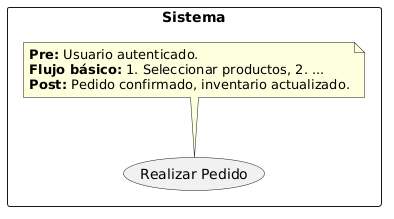

In [19]:
# Diagrama PlantUML
plantuml_code = '''@startuml
rectangle "Sistema" {
    usecase "Realizar Pedido" as RP
    note top of RP
      <b>Pre:</b> Usuario autenticado.
      <b>Flujo básico:</b> 1. Seleccionar productos, 2. ...
      <b>Post:</b> Pedido confirmado, inventario actualizado.
    end note
}
@enduml'''

render_plantuml(plantuml_code)



No obstante, sobrecargar el diagrama con todo el contenido textual suele ir en detrimento de la legibilidad. Por ello, reservo esta técnica para resúmenes ejecutivos o para la documentación embebida en la propia imagen.

### 5.3.2 Notas con formato Creole

Las notas (`note left of`, `note right of`, `note top of`, `note bottom of`) admiten el uso de Creole (negritas, cursivas, subrayados, listas) y HTML básico (sección 1.19 del manual). Así podemos incluir aclaraciones breves sin abandonar el lienzo del diagrama:



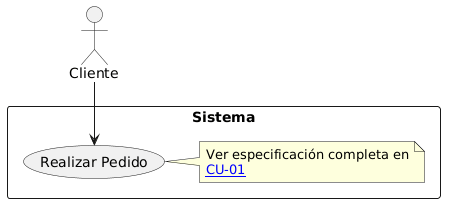

In [20]:
# Diagrama PlantUML
plantuml_code = '''@startuml
:Cliente: as C

rectangle "Sistema" {
    (Realizar Pedido) as RP
    note right of RP
      Ver especificación completa en
      [[./docs/CU-01.md CU-01]]
    end note
}

C --> RP
@enduml'''

render_plantuml(plantuml_code)



### 5.3.3 Enlaces a la documentación externa

La solución que mejor equilibra claridad visual y profundidad documental es enlazar el caso de uso a su especificación detallada, alojada por ejemplo en un archivo Markdown versionado junto al código. PlantUML permite crear hipervínculos con la sintaxis `[[URL]]` o `[[URL texto]]` tanto en el nombre del caso de uso como en las notas (sección 22.7 de la guía).



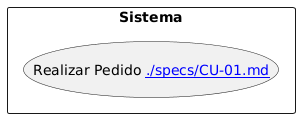

In [21]:
# Diagrama PlantUML
plantuml_code = '''@startuml
rectangle "Sistema" {
    usecase "Realizar Pedido [[./specs/CU-01.md]]" as RP
}
@enduml'''

render_plantuml(plantuml_code)



De este modo, el diagrama funciona como índice navegable y cualquier interesado puede acceder al detalle completo con un solo clic.

## 5.4. Buenas prácticas para redactar especificaciones útiles

Tras años escribiendo y revisando casos de uso, he interiorizado algunas reglas que marcan la diferencia entre un documento que se usa y uno que se archiva:

- **Claridad ante todo**: frases cortas, lenguaje natural, sin jerga de programación. Quien lea la especificación no debería necesitar conocimientos técnicos para entender el comportamiento del sistema.
- **Especificar sin diseñar**: el flujo básico describe *qué* hace el sistema, no *cómo* lo hace internamente. No debe mencionar bases de datos, botones de interfaz o nombres de clases. Ese detalle pertenece al diseño, no al análisis.
- **Narrativa coherente**: cada paso debe fluir del anterior. Un buen truco es leer el flujo en voz alta; si suena antinatural o hay saltos lógicos, algo necesita revisarse.
- **Cubrir los casos de error**: no limitarse al camino feliz. Dedicar tiempo a los flujos de excepción evita sorpresas en etapas avanzadas. Si no se documentan, nadie los programa.
- **Mantenimiento vivo**: la especificación debe actualizarse cuando cambien los requisitos. Al estar escrita en texto plano y almacenada en un repositorio (Git), se beneficia de las mismas prácticas de control de versiones que el código fuente.
- **Un caso de uso por documento**: evita ficheros monolíticos. Asociar cada especificación a un archivo independiente (por ejemplo, CU-01.md, CU-02.md) facilita la edición y la revisión entre pares.
- **Validar con el actor principal**: antes de considerarla terminada, la especificación debe ser revisada por alguien que represente el rol del actor principal. Su retroalimentación es oro puro.

En resumen, el diagrama de casos de uso es la puerta de entrada, pero la especificación textual es la estancia donde realmente se cocina el software. Dominar su redacción es una habilidad que todo ingeniero de software debe cultivar, pues en ella se funden la comprensión del negocio, la precisión técnica y la comunicación efectiva con todo el equipo.

### Ejercicio práctico: completa la especificación

Toma el caso de uso **CU-01: Realizar Pedido** y completa su especificación usando la plantilla anterior. Como ayuda, aquí tienes el flujo básico ya redactado:

> 1. El Cliente solicita iniciar un nuevo pedido.
> 2. El Sistema presenta el catálogo de productos.
> 3. El Cliente selecciona productos y cantidades.
> 4. El Sistema agrega al carrito y muestra resumen.
> 5. El Cliente confirma el pedido.
> 6. El Sistema solicita la dirección de envío.
> 7. El Cliente ingresa la dirección.
> 8. El Sistema calcula costos e impuestos y muestra total.
> 9. El Cliente autoriza el pago.
> 10. El Sistema procesa el pago, actualiza inventario, genera pedido y envía correo.

Ahora completa:

1. **Identificación**: asigna un código, actor principal, actores secundarios y prioridad.
2. **Precondiciones**: escribe al menos dos condiciones que deben cumplirse antes del paso 1.
3. **Flujo alternativo**: imagina que en el paso 9 el cliente elige PayPal en lugar de tarjeta. Describe los pasos.
4. **Flujo de excepción**: describe qué ocurre si en el paso 10 la pasarela de pago rechaza la transacción.
5. **Postcondiciones**: enumera tres estados verificables tras la ejecución exitosa.
6. **Requisito especial**: añade un requisito de rendimiento (ej. tiempo máximo de respuesta).

Puedes validar tu solución contrastándola con el código de ejemplo en la sección 3.3, donde CU-01 se implementa en Python.

---
# 6. Organización Visual con Paquetes: Domando la Complejidad

A medida que un sistema crece, la cantidad de casos de uso y actores puede volverse abrumadora. Un diagrama con treinta elipses y quince monigotes no comunica; confunde. Para mantener la claridad, UML nos ofrece un mecanismo de agrupación lógica llamado **paquete** (*package*). Un paquete es, en esencia, un contenedor que reúne elementos relacionados —casos de uso, actores e incluso otros paquetes— bajo un nombre común que refleja un módulo, subsistema o área funcional del sistema.

> **UML estándar vs. PlantUML:** En UML estándar, un paquete se representa como una carpeta con pestaña. PlantUML respeta esta convención por defecto (`skinparam packageStyle folder`) pero ofrece variantes: `rectangle`, `node`, `frame`, `cloud`, `database`. La semántica UML (contenedor lógico) es la misma; solo cambia la apariencia visual.

**Perspectiva PM:** Los paquetes son mi herramienta para delegar. Cuando el sistema crece, asigno cada paquete a un equipo de desarrollo diferente. "Vosotros os encargáis del paquete Pagos, vosotros del paquete Catálogo". Esto me permite granularizar el plan de proyecto y hacer seguimiento por módulo.

**Perspectiva desarrollador:** Los paquetes en el diagrama de casos de uso se corresponden directamente con módulos, namespaces o paquetes en el código fuente. Si el diagrama tiene un paquete "Gestión de Pagos", espero encontrar un directorio `app/pagos/` con sus controladores, servicios y pruebas. La coherencia entre la estructura del diagrama y la del código reduce la fricción al navegar el proyecto.

**Perspectiva analista:** Cuando organizo los casos de uso en paquetes, estoy modelando la estructura del negocio, no la de la tecnología. Un paquete "Gestión Académica" refleja un área organizativa, no una capa de la base de datos. Esta distinción es crucial para que el diagrama sea legible por stakeholders no técnicos.

PlantUML soporta plenamente los paquetes y ofrece múltiples variantes visuales que podemos configurar según el contexto. En este tema exploraremos cómo declararlos, cómo anidarlos, cómo aplicarlos tanto a casos de uso como a actores, y qué prácticas aseguran que nuestros diagramas sigan siendo un activo de comunicación incluso cuando el sistema escala a cientos de funcionalidades.

## 6.1. ¿Por qué necesitamos paquetes? El problema del diagrama monolítico

Imaginemos un sistema de gestión universitaria. Tenemos casos de uso como "Matricular Asignatura", "Generar Acta de Calificaciones", "Gestionar Expediente Académico", "Solicitar Beca", "Pagar Matrícula", "Consultar Biblioteca", "Reservar Laboratorio", etc. Los actores incluyen Alumno, Profesor, Administrativo, Director de Departamento, un Sistema de Pago Externo, un Sistema de Autenticación Institucional y varios más.

Si dibujamos todo en un solo lienzo sin agrupar, el resultado será una maraña incomprensible. Pero si agrupamos los casos de uso por subsistemas —"Gestión Académica", "Servicios Financieros", "Biblioteca", "Recursos Físicos"— y organizamos a los actores según su ámbito, el mismo diagrama se convierte en un mapa navegable. Un stakeholder del área financiera puede ignorar las burbujas de "Biblioteca" y centrarse en las de "Servicios Financieros". Un desarrollador asignado a un módulo puede ver exactamente qué casos de uso le competen y cómo se relacionan con actores de otras áreas.

## 6.2. Concepto de paquete en UML y su representación en PlantUML

En UML, un paquete es un espacio de nombres contenedor. Su representación clásica es una carpeta (un rectángulo grande con una pestaña en la esquina superior izquierda). Sin embargo, PlantUML es flexible y nos permite cambiar esta apariencia mediante el comando `skinparam packageStyle` o aplicando estereotipos específicos a cada paquete.

La sintaxis fundamental en PlantUML es la palabra reservada `package` seguida del nombre (opcionalmente entre comillas si contiene espacios o caracteres especiales). El contenido del paquete se delimita con llaves `{ ... }`. Todo lo declarado dentro de las llaves pertenece a ese paquete y se dibuja dentro de su frontera.

Un ejemplo mínimo:



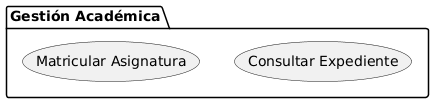

In [22]:
# Diagrama PlantUML
plantuml_code = '''@startuml
package "Gestión Académica" {
  (Matricular Asignatura)
  (Consultar Expediente)
}
@enduml'''

render_plantuml(plantuml_code)



Este fragmento genera una carpeta etiquetada "Gestión Académica" que contiene dos casos de uso. Visualmente, los casos de uso aparecen dentro del rectángulo del paquete, estableciendo una pertenencia clara.

## 6.3. Variantes visuales de paquetes en PlantUML

La guía de PlantUML (página 73) documenta que podemos modificar la apariencia de los paquetes mediante `skinparam packageStyle` seguido de uno de estos valores:

- `folder` (predeterminado): dibuja la clásica carpeta con pestaña.
- `rectangle`: dibuja un rectángulo simple sin pestaña.
- `node`: dibuja un nodo tridimensional.
- `frame`: dibuja un marco con borde grueso.
- `cloud`: dibuja una nube, útil para indicar límites difusos o externos.
- `database`: dibuja un cilindro de base de datos.

También podemos aplicar un estereotipo directamente en la declaración del paquete, como `package "Nombre" <<Node>>`, lo que permite que cada paquete tenga un estilo distinto en el mismo diagrama.

Un ejemplo con varios estilos:



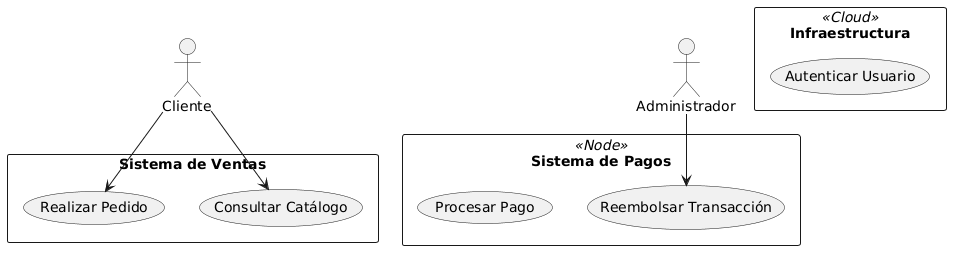

In [23]:
# Diagrama PlantUML
plantuml_code = '''@startuml
skinparam packageStyle rectangle

package "Sistema de Ventas" {
  usecase "Realizar Pedido" as RP
  usecase "Consultar Catálogo" as CC
}

package "Sistema de Pagos" <<Node>> {
  usecase "Procesar Pago" as PP
  usecase "Reembolsar Transacción" as RT
}

package "Infraestructura" <<Cloud>> {
  usecase "Autenticar Usuario" as AU
}

:Cliente: --> RP
:Cliente: --> CC
:Administrador: --> RT
@enduml'''

render_plantuml(plantuml_code)



Aquí "Sistema de Ventas" se dibuja como rectángulo (por el `skinparam` global), pero "Sistema de Pagos" adopta la forma de nodo y "Infraestructura" la de nube, gracias a los estereotipos individuales. Esta combinación permite jerarquizar visualmente los subsistemas y destacar aquellos que son externos o cuya frontera es menos definida.

## 6.4. Anidamiento de paquetes

Los paquetes pueden contener otros paquetes, reflejando la descomposición jerárquica de un sistema en subsistemas, módulos y submódulos. La sintaxis es simplemente colocar un bloque `package` dentro de otro:



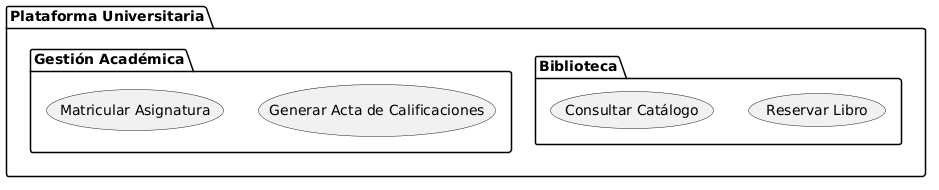

In [24]:
# Diagrama PlantUML
plantuml_code = '''@startuml
package "Plataforma Universitaria" {
  package "Gestión Académica" {
    (Matricular Asignatura)
    (Generar Acta de Calificaciones)
  }
  package "Biblioteca" {
    (Consultar Catálogo)
    (Reservar Libro)
  }
}
@enduml'''

render_plantuml(plantuml_code)



El resultado muestra "Plataforma Universitaria" como el paquete raíz, y dentro de él, "Gestión Académica" y "Biblioteca" como subpaquetes, cada uno con sus respectivos casos de uso. Este anidamiento puede tener tantos niveles como sea necesario, aunque conviene no exceder tres o cuatro para mantener la legibilidad.

## 6.5. Agrupación de actores con paquetes

No solo los casos de uso se benefician de la agrupación; los actores también pueden organizarse en paquetes. Esto es particularmente útil cuando el sistema interactúa con múltiples departamentos de una organización o con diferentes sistemas externos.

La guía de PlantUML (páginas 46-47 en la sección de casos de uso, y ejemplos en las secciones de despliegue) muestra cómo declarar actores dentro de paquetes. La sintaxis es idéntica: los actores se colocan dentro del bloque `package` correspondiente.



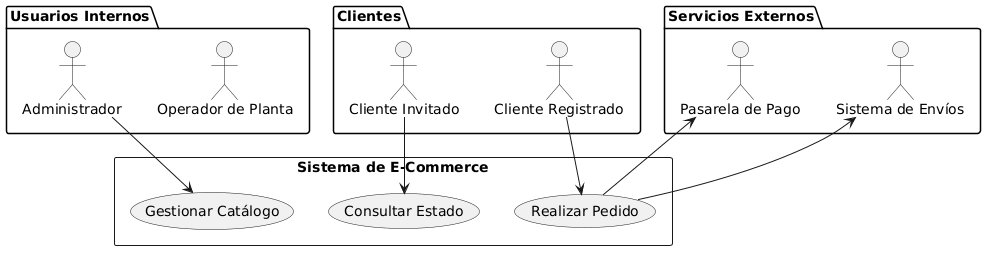

In [25]:
# Diagrama PlantUML
plantuml_code = '''@startuml
package "Usuarios Internos" {
  actor Administrador as Admin
  actor "Operador de Planta" as Op
}

package "Clientes" {
  :Cliente Registrado: as Cli
  :Cliente Invitado: as Inv
}

package "Servicios Externos" {
  :Pasarela de Pago: as Pay
  :Sistema de Envíos: as Env
}

rectangle "Sistema de E-Commerce" {
  (Realizar Pedido) as RP
  (Gestionar Catálogo) as GC
  (Consultar Estado) as CE
}

Cli --> RP
Inv --> CE
Admin --> GC
Pay <-- RP
Env <-- RP
@enduml'''

render_plantuml(plantuml_code)



Observen cómo los actores están agrupados según su naturaleza —usuarios internos, clientes, servicios externos— y el sistema bajo diseño se representa con un rectángulo que encierra los casos de uso. Esta disposición deja claro quién pertenece a qué ámbito y cómo se conectan los distintos grupos.

## 6.6. Relaciones entre paquetes

En sistemas grandes, no solo los casos de uso individuales se relacionan; los propios paquetes pueden tener dependencias entre sí. UML permite dibujar flechas de dependencia entre paquetes para indicar que el contenido de un paquete conoce o requiere elementos de otro. Aunque no es una práctica obligatoria en diagramas de casos de uso, puede ser útil para mostrar acoplamientos en alto nivel.

PlantUML nos permite trazar flechas entre paquetes igual que entre cualquier otro elemento:



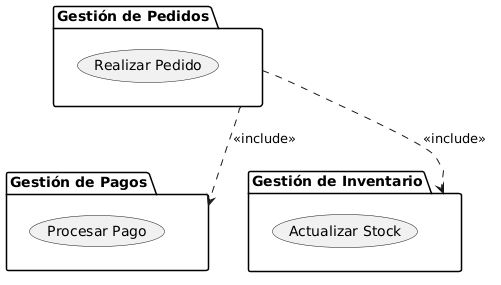

In [26]:
# Diagrama PlantUML
plantuml_code = '''@startuml
package "Gestión de Pedidos" as GPe {
  (Realizar Pedido)
}
package "Gestión de Pagos" as GPa {
  (Procesar Pago)
}
package "Gestión de Inventario" as GI {
  (Actualizar Stock)
}

GPe ..> GPa : <<include>>
GPe ..> GI : <<include>>
@enduml'''

render_plantuml(plantuml_code)



Aquí las flechas no conectan casos de uso directamente, sino los paquetes que los contienen, indicando que "Gestión de Pedidos" depende de "Gestión de Pagos" y de "Gestión de Inventario". Es una vista arquitectónica complementaria al detalle funcional interno de cada paquete.

## 6.7. Mejores prácticas para organizar paquetes en casos de uso

Después de muchas discusiones de diseño, he llegado a algunas reglas que ayudan a mantener los diagramas con paquetes limpios y útiles:

- **Agrupar por cohesión funcional, no por capa técnica**: los paquetes deben reflejar áreas del negocio ("Gestión de Pedidos", "Facturación", "Atención al Cliente"), no capas de la arquitectura ("Frontend", "Backend", "Base de Datos"). El diagrama de casos de uso describe el sistema desde la perspectiva del usuario, no su estructura interna.
- **Un actor puede aparecer fuera de los paquetes del sistema si es transversal**: actores como "Administrador del Sistema" o "Auditor de Seguridad" que interactúan con múltiples subsistemas pueden colocarse fuera de cualquier paquete, con sus líneas de asociación cruzando las fronteras de los paquetes del sistema.
- **Evitar más de tres niveles de anidamiento**: si un paquete tiene subpaquetes, y esos tienen subsubpaquetes, la legibilidad se resiente. Si se necesita más profundidad, tal vez sea el momento de dividir en varios diagramas separados.
- **Nombrar los paquetes con frases sustantivas**: "Gestión de Pedidos" es mejor que "Módulo 1" o "Paquete A". El nombre debe transmitir de inmediato el ámbito funcional.
- **Usar colores y estilos con moderación**: un color de fondo suave puede ayudar a distinguir un paquete externo (por ejemplo, un sistema de terceros) de los internos. Pero un arcoíris de colores distrae y puede hacer que el diagrama parezca un catálogo de pinturas en lugar de un modelo serio. La guía de PlantUML permite especificar colores con `#color` después del nombre del paquete: `package "Externo" #LightYellow { ... }`.
- **Consistencia visual en toda la documentación**: si en un diagrama "Sistema de Pagos" se dibuja con estilo `node`, en todos los diagramas del proyecto debería verse igual. Esto refuerza el reconocimiento visual y reduce la carga cognitiva.

## 6.8. Dirección del diagrama: mejorando la legibilidad con `left to right direction`

Un detalle que la guía de PlantUML menciona en la sección de casos de uso (páginas 52-53) y que es especialmente útil cuando trabajamos con paquetes y muchos casos de uso es la directiva `left to right direction`. Por defecto, PlantUML tiende a organizar los elementos de arriba hacia abajo. Con paquetes que contienen múltiples casos de uso, esto puede generar diagramas muy alargados verticalmente. Cambiar la dirección a izquierda-derecha a menudo produce una disposición más compacta y legible.



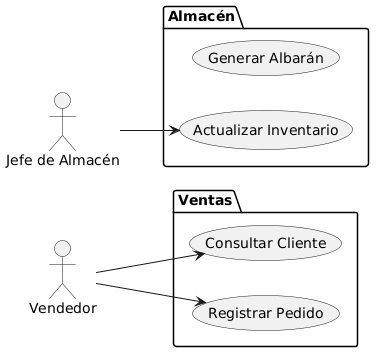

In [27]:
# Diagrama PlantUML
plantuml_code = '''@startuml
left to right direction
package "Ventas" {
  (Registrar Pedido)
  (Consultar Cliente)
}
package "Almacén" {
  (Actualizar Inventario)
  (Generar Albarán)
}
:Vendedor: --> (Registrar Pedido)
:Vendedor: --> (Consultar Cliente)
:Jefe de Almacén: --> (Actualizar Inventario)
@enduml'''

render_plantuml(plantuml_code)



La diferencia visual es notable y, en muchos casos, permite aprovechar mejor el espacio horizontal de las pantallas y los documentos.

## 6.9. Ejemplo completo integrador

Para cerrar este tema, presento un diagrama más elaborado que muestra cómo se combinan actores agrupados, un sistema con múltiples paquetes, un paquete para un sistema externo y anidamiento de un subpaquete, todo ello con estilos diferenciados y dirección izquierda-derecha.



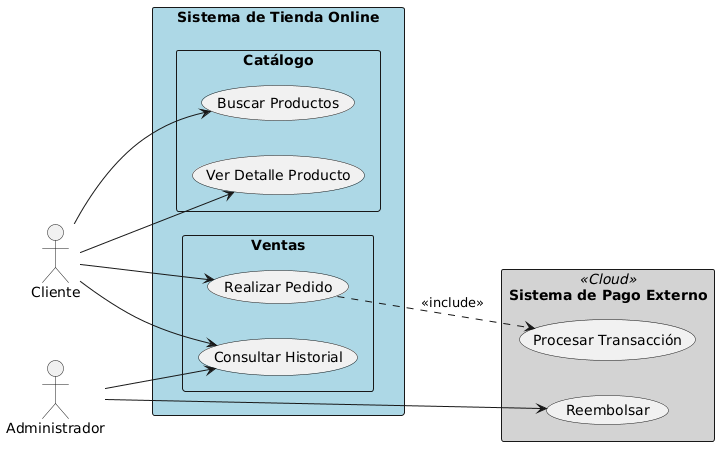

In [28]:
# Diagrama PlantUML
plantuml_code = '''@startuml
left to right direction
skinparam packageStyle rectangle

actor "Cliente" as C
actor "Administrador" as A

package "Sistema de Tienda Online" #LightBlue {
  package "Catálogo" {
    (Buscar Productos) as BP
    (Ver Detalle Producto) as VDP
  }
  package "Ventas" {
    (Realizar Pedido) as RP
    (Consultar Historial) as CH
  }
}

package "Sistema de Pago Externo" <<Cloud>> #LightGray {
  (Procesar Transacción) as PT
  (Reembolsar) as Re
}

C --> BP
C --> VDP
C --> RP
C --> CH
A --> CH
A --> Re
RP ..> PT : <<include>>
@enduml'''

render_plantuml(plantuml_code)



Este ejemplo refleja un escenario realista: el "Sistema de Tienda Online" contiene dos subpaquetes ("Catálogo" y "Ventas") que agrupan funcionalidades relacionadas, mientras que el "Sistema de Pago Externo" se representa como una nube para indicar que está fuera de nuestra frontera de desarrollo. Los actores se sitúan fuera de los paquetes porque interactúan con múltiples partes del sistema.

## 6.10. Conexión con el prototipado de interfaz

Un diagrama de casos de uso con paquetes no solo organiza funcionalidades; es el punto de partida ideal para el prototipado de la interfaz de usuario. Cada paquete puede asignarse a una sección de la aplicación (un menú, un módulo, una pantalla principal), y cada caso de uso dentro del paquete se traduce en una o más vistas concretas.

Por ejemplo, si el paquete "Catálogo" contiene los casos de uso "Buscar Productos" y "Ver Detalle Producto", el prototipo correspondiente tendrá una pantalla de búsqueda con filtros y una pantalla de detalle con foto, descripción y precio. El flujo básico de "Realizar Pedido" define la secuencia de pantallas que el prototipo debe reflejar: carrito → dirección → pago → confirmación.

**Perspectiva desarrollador:** Tener el prototipo alineado con los casos de uso acelera el desarrollo porque sé exactamente qué pantalla implementar para cada caso de uso y qué flujo de navegación debe seguir el usuario. Si el prototipo muestra un paso que no está en la especificación, es una señal de alerta que detectamos antes de escribir código.

**Perspectiva PM:** Cuando presento el prototipo a un stakeholder, no digo "esta es la pantalla de pago"; digo "este es el paso 9 del caso de uso Realizar Pedido". El stakeholder entiende que no está viendo un diseño aislado, sino una pieza de una historia funcional completa. Esto alinea las expectativas y reduce los cambios de última hora.

Herramientas como Figma, Balsamiq o Adobe XD permiten enlazar cada pantalla a un caso de uso mediante metadatos o naming conventions. El resultado es una trazabilidad visual que complementa la documentación textual y cierra el círculo entre el análisis funcional y el diseño de interacción.

Con esto, dominar la organización visual con paquetes les permitirá modelar sistemas de cualquier envergadura sin sacrificar la claridad. En el próximo tema, abordaremos los beneficios que todo este aparato de modelado con casos de uso aporta a la gestión de proyectos de software, desde la toma de requisitos hasta la validación con usuarios.

# 7. Beneficios desde la Trinchera del Análisis Funcional: Por qué los Casos de Uso son el Lenguaje Común del Proyecto

A lo largo de mi trayectoria como responsable de proyectos de software, he visto equipos descarrilarse porque cada interlocutor manejaba una visión distinta del sistema: el cliente hablaba de necesidades de negocio, los desarrolladores de módulos y APIs, los testers de escenarios de prueba, y el director financiero de partidas presupuestarias. Los casos de uso, cuando se utilizan con rigor, actúan como el esperanto que unifica todos estos dialectos. No son un mero artefacto UML para decorar la documentación; son la columna vertebral del análisis funcional y proporcionan beneficios concretos que transforman la manera en que concebimos, validamos y comunicamos el software. En este tema quiero mostrarles cómo, desde la especificación y el modelado de casos de uso, se derivan ventajas tangibles para delimitar el alcance, estimar el esfuerzo, establecer prioridades, diseñar pruebas de aceptación y comunicar con eficacia a todos los involucrados, sin necesidad de recurrir a cronogramas ni diagramas de Gantt.

## 7.1. Definición precisa del alcance funcional

El problema más recurrente en los proyectos de software es la expansión descontrolada del alcance: aparecen funcionalidades que nadie pidió, se olvidan requisitos críticos y el sistema resultante no se corresponde con lo que los usuarios esperaban. Los casos de uso atacan este problema desde la raíz porque obligan a responder una pregunta muy concreta: ¿qué objetivos de valor puede alcanzar cada tipo de usuario con el sistema?

Cada elipse del diagrama representa una funcionalidad completa, significativa y verificable desde el punto de vista del actor. Si un requisito no puede expresarse como un caso de uso —es decir, no hay un actor que obtenga un resultado valioso al ejecutarlo—, probablemente no pertenece al sistema que estamos construyendo, sino a sus mecanismos internos o a la infraestructura, y debe documentarse en otro lugar. Esta restricción conceptual es enormemente disciplinante.

Cuando elaboramos la especificación textual, cada paso del flujo básico añade un nivel adicional de concreción. Ya no estamos hablando genéricamente de "gestionar pedidos", sino de una secuencia detallada de interacciones que, si se implementa correctamente, satisface el objetivo del actor. Las precondiciones y postcondiciones definen con exactitud qué estado debe tener el sistema antes y después de cada caso de uso, estableciendo fronteras nítidas entre funcionalidades.

Además, las relaciones entre casos de uso —inclusión, extensión y generalización— nos ayudan a descomponer el alcance sin perder la visión de conjunto. La inclusión nos permite extraer comportamientos compartidos que, de otro modo, aparecerían duplicados en varios lugares (y se estimarían o implementarían dos veces). La extensión nos da un mecanismo controlado para posponer funcionalidades opcionales sin que el caso de uso base pierda su integridad. La generalización nos permite organizar variantes de un mismo objetivo familiar, como "Pago con Tarjeta" y "Pago con PayPal", que comparten estructura pero difieren en detalles.

Desde la óptica del análisis funcional, un conjunto completo y bien relacionado de casos de uso es la definición más precisa que podemos ofrecer sobre qué hace el sistema y qué no hace. Cualquier intento de añadir una nueva funcionalidad se enfrenta a la pregunta inevitable: ¿qué caso de uso cubre esto? Si no hay respuesta, toca sentarse con los interesados y decidir si se amplía el alcance o se reserva para una fase posterior.

## 7.2. Base sólida para estimar el esfuerzo

Estimar cuánto trabajo requiere un sistema es una tarea compleja, pero los casos de uso la simplifican porque proporcionan una granularidad adecuada para el análisis. Un caso de uso como "Realizar Pedido" no es ni tan pequeño como una función atómica (que sería demasiado detallada para una estimación de alto nivel) ni tan grande como un subsistema completo (que sería demasiado difuso); es una unidad de valor que los desarrolladores pueden visualizar y dimensionar.

La especificación textual permite afinar la estimación porque expone la complejidad real del caso de uso más allá de su nombre. No es lo mismo "Realizar Pedido" con un flujo básico de diez pasos y dos flujos alternativos sencillos que "Realizar Pedido" con siete flujos alternativos, cinco flujos de excepción, integración con tres sistemas externos, y requisitos especiales de seguridad y auditoría. La especificación nos da los elementos para distinguir entre ambas situaciones y asignar un esfuerzo proporcional.

Cada componente de la especificación aporta información para la estimación:
- Los pasos del flujo básico sugieren la cantidad de interacciones que deben implementarse.
- Los flujos alternativos indican variantes que requieren lógica condicional adicional.
- Los flujos de excepción revelan la necesidad de manejo de errores y pruebas de resiliencia.
- Los actores secundarios apuntan a integraciones con sistemas externos, a menudo impredecibles y costosas.
- Los requisitos especiales pueden disparar trabajo adicional de infraestructura, seguridad o cumplimiento normativo.

Con esta información, un equipo técnico puede asignar magnitudes relativas a cada caso de uso (por ejemplo, mediante planning poker o tallas de camiseta) y obtener una visión global del esfuerzo esperado sin necesidad de descomponer en tareas de código. La suma de esas estimaciones, ponderada por la prioridad y las dependencias, proporciona una base racional para la toma de decisiones sobre viabilidad del proyecto.

## 7.3. Priorización basada en valor y riesgo

No todos los casos de uso son igual de importantes. Algunos representan la esencia del sistema, aquellos sin los cuales el software no tendría razón de ser. Otros son accesorios, deseables pero no indispensables. Los casos de uso nos dan el lenguaje para discutir estas diferencias con los stakeholders de forma objetiva.

Desde el análisis funcional, la priorización suele atender a dos criterios principales: el valor que el caso de uso aporta al actor principal y el riesgo técnico o de negocio asociado a su implementación. Un caso de uso como "Realizar Pedido" en un sistema de comercio electrónico es de altísimo valor porque sin él no hay transacción posible, y su implementación puede entrañar riesgos de integración con la pasarela de pago. Frente a él, "Personalizar Recomendaciones" puede ser valioso pero no crítico, y además requerir algoritmos de machine learning que introducen incertidumbre técnica.

La especificación textual ayuda a evaluar ambos criterios:
- El propósito y el flujo básico dejan claro el valor para el actor principal.
- Las precondiciones, los actores secundarios y los requisitos especiales revelan puntos de riesgo: dependencias externas, requisitos de rendimiento estrictos, restricciones legales, etcétera.
- Los flujos alternativos y de excepción pueden indicar complejidad oculta y posibles fuentes de defectos.

Con esta evaluación, el equipo puede ordenar los casos de uso en una secuencia de implementación que maximice el valor entregado en las primeras etapas y minimice la exposición al riesgo. Esta priorización no depende de ninguna herramienta de planificación temporal; es una decisión puramente funcional que luego se podrá reflejar en cualquier cronograma, pero cuya lógica descansa enteramente en el modelo de casos de uso.

## 7.4. Diseño de pruebas de aceptación directamente desde los casos de uso

Una de las ventajas más prácticas de los casos de uso es que se traducen de manera casi directa en escenarios de prueba de aceptación. Cada flujo —básico, alternativo y de excepción— describe una secuencia de acciones y respuestas del sistema que puede convertirse en un guion de prueba, con entradas, condiciones previas y resultados esperados perfectamente definidos.

Para el flujo básico de "Realizar Pedido", el escenario de prueba correspondiente replicará los pasos exactos: se autentica al cliente, se seleccionan productos, se ingresa una dirección de envío, se confirma el pago con tarjeta válida, y se verifica que el pedido queda registrado, el inventario actualizado y el correo de confirmación enviado. Las postcondiciones de la especificación textual se convierten en los criterios de aceptación que el tester debe comprobar.

Los flujos alternativos generan escenarios de prueba adicionales. Si existe un flujo alternativo "Pago con PayPal", el tester ejecutará el mismo caso de uso pero elegirá PayPal en el paso correspondiente y verificará la redirección, la autenticación en el entorno de PayPal y la vuelta al sistema con la confirmación.

Los flujos de excepción son especialmente valiosos para las pruebas negativas. El escenario "Producto sin stock" se prueba agotando deliberadamente el inventario de un producto e intentando añadirlo al carrito, verificando que el sistema muestra el mensaje adecuado y no permite continuar. El escenario "Pago rechazado" se prueba con una tarjeta que la pasarela deniega, comprobando que el sistema reacciona con un mensaje claro y permite reintroducir datos o elegir otro método.

Esta trazabilidad entre casos de uso y pruebas de aceptación tiene un valor inmenso para el aseguramiento de la calidad: cada caso de uso genera un conjunto bien definido de pruebas que cubre no solo el camino feliz, sino también las desviaciones y los errores. Además, al estar los casos de uso vinculados a los actores, las pruebas pueden organizarse por perfil de usuario, facilitando la planificación de sesiones de validación con usuarios reales representativos de cada rol.

## 7.5. Comunicación efectiva con todos los stakeholders

Quizás el beneficio más transformador de los casos de uso es que proporcionan un lenguaje común para todos los involucrados en el proyecto. He visto cómo un diagrama de casos de uso bien estructurado, complementado con especificaciones textuales claras, puede alinear a un equipo multidisciplinar como ningún otro artefacto.

Para el cliente o el usuario final, los casos de uso hablan su idioma. No mencionan bases de datos, colas de mensajes ni patrones de diseño; cuentan historias sobre lo que el usuario puede hacer con el sistema. Un director comercial entiende perfectamente qué significa "Realizar Pedido", "Consultar Estado" o "Aplicar Descuento", y puede validar si esas historias reflejan sus procesos reales.

Para el equipo de desarrollo, los casos de uso proporcionan el contexto funcional que da sentido a las tareas técnicas. Cuando un programador sabe que está implementando el paso 8 del flujo básico de "Realizar Pedido" —el cálculo de costos de envío e impuestos—, entiende por qué esa funcionalidad es necesaria, qué datos necesita y qué resultado debe producir. No programa en el vacío; programa una pieza de una historia más grande.

Para los testers, como ya hemos visto, los casos de uso son la materia prima de los escenarios de prueba. Pueden leer la misma especificación que el desarrollador y extraer de ella lo que necesitan para verificar el sistema, sin tener que traducir desde un documento técnico diferente.

Para los analistas de negocio y los responsables de producto, los casos de uso organizan el alcance de manera que se puede discutir, modificar y ampliar sin perderse en detalles técnicos. Las relaciones de inclusión, extensión y generalización les permiten razonar sobre la modularidad funcional del sistema sin necesidad de conocer su arquitectura interna.

Y para los directores de proyecto, los casos de uso ofrecen una visión clara de qué funcionalidades están planificadas, cuáles son sus dependencias funcionales (a través de inclusiones y precondiciones) y cuál es su completitud (si un caso de uso tiene todos sus flujos especificados o solo el básico). Esta información, obtenida exclusivamente del análisis funcional, es suficiente para mantener discusiones informadas sobre el progreso y la cobertura sin necesidad de recurrir a diagramas temporales.

La organización visual con paquetes, que exploramos en el tema anterior, potencia aún más esta comunicación, porque permite presentar el sistema a diferentes audiencias con el nivel de detalle adecuado: una vista de alto nivel con los paquetes principales para la dirección, y vistas detalladas de cada paquete para los equipos de desarrollo asignados a cada subsistema.

## 7.6. Trazabilidad bidireccional: del caso de uso al código y a las pruebas

Un modelo de casos de uso no está completo hasta que sus elementos son trazables a lo largo del ciclo de vida del proyecto. Cada caso de uso debería poder rastrearse desde el diagrama hasta el código que lo implementa, pasando por las pruebas que lo verifican. Esta trazabilidad no es un lujo; es una necesidad cuando el sistema evoluciona y hay que evaluar el impacto de los cambios.

**Perspectiva desarrollador:** En mi flujo de trabajo, cada caso de uso tiene un identificador (CU-01, CU-02) que uso como referencia en los commits, en los nombres de archivos y en los decoradores de las rutas de la API:



In [ ]:
# git commit message: "feat: implementa CU-01 Realizar Pedido"
# app/api/pedidos.py
@router.post("/pedidos", tags=["CU-01"])
def realizar_pedido(pedido: PedidoRequest):
    resultado = ejecutar_caso_uso_cu01(pedido)
    return JSONResponse(resultado, status_code=201)



También usamos ese identificador en los tests:



In [ ]:
# tests/test_cu01_realizar_pedido.py
def test_flujo_basico_cu01():
    """Cubre el flujo básico de CU-01 (pasos 1-10)."""
    response = client.post("/pedidos", json=payload_valido)
    assert response.status_code == 201

def test_excepcion_stock_insuficiente_cu01():
    """Cubre flujo de excepción: producto sin stock."""
    ...



Esta convención permite responder preguntas como "¿qué commits implementan CU-01?" (git log --grep="CU-01") o "¿qué pruebas cubren este caso de uso?" (pytest -k "cu01").

**Perspectiva PM:** La trazabilidad me da visibilidad sobre el progreso real. Si veo CU-01 en el diagrama pero no hay commits con esa referencia, sé que aún no se ha implementado. Si hay pruebas pero la API no tiene el endpoint correspondiente, hay una brecha. Esta información la obtengo sin preguntar al equipo; solo consultando el repositorio.

En síntesis, los casos de uso no son simplemente un ejercicio de modelado UML. Son el pegamento que une las perspectivas de negocio, desarrollo, calidad y gestión en un entendimiento compartido y verificable de lo que el sistema debe hacer. Dominarlos es, por tanto, una de las habilidades más rentables que puede adquirir un ingeniero de software.

# 8. Cierre y Buenas Prácticas en el Modelado de Casos de Uso: Errores Frecuentes, Consejos de Notación y el Valor Duradero del Análisis Funcional

Hemos recorrido un camino extenso. Desde la esencia de un caso de uso como narrativa de valor, pasando por los actores y sus roles, las relaciones que estructuran la funcionalidad, la especificación textual como corazón del análisis y la organización mediante paquetes, hasta los beneficios tangibles que todo este aparato conceptual aporta al proyecto de software. Ha llegado el momento de consolidar lo aprendido, de poner sobre la mesa los tropiezos más comunes que he observado en equipos de desarrollo —y que yo mismo he cometido—, de establecer pautas de notación que mantengan los diagramas claros y mantenibles, y de reflexionar sobre el valor duradero que el modelado de casos de uso aporta a la ingeniería de software más allá de las modas metodológicas.

> **UML estándar vs. PlantUML:** A lo largo de este documento hemos usado PlantUML como herramienta de representación, pero los conceptos, las relaciones y las buenas prácticas que discutimos aquí son UML puro. PlantUML es un medio conveniente para generar diagramas desde texto, pero el valor real está en el modelo conceptual que construyes. No dependas de una herramienta; domina el modelado.

**Perspectiva desarrollador:** Los errores que enumero a continuación no son teóricos. Los he visto causar bugs en producción, duplicación de código y semanas de retrabajo. Si algo he aprendido es que un caso de uso mal definido al principio cuesta 10 veces más de corregir al final. Tomarse el tiempo para hacerlo bien en la fase de análisis es la inversión más rentable que puedes hacer.

## 8.1. Errores frecuentes al modelar casos de uso

La práctica de modelar casos de uso es engañosamente sencilla. Dibujar óvalos y monigotes está al alcance de cualquiera, pero hacerlo con rigor y que el resultado sea útil para el equipo exige disciplina. Estos son los errores que me he encontrado una y otra vez, y que quiero que ustedes eviten desde el primer día.

### 8.1.1. Confundir casos de uso con funciones del sistema

Es el pecado original del modelador novato. En lugar de "Realizar Pedido", escribe "Validar Email", "Enviar Notificación" o "Insertar Registro en Base de Datos". Estas son funciones atómicas, no objetivos de usuario. Un caso de uso debe representar una meta completa y significativa para el actor. Una prueba de fuego que aplico siempre es preguntar: "¿Se levanta el actor de su silla y se va satisfecho después de ejecutar esto?". Si la respuesta es no, probablemente lo que tengo es un paso de un flujo, no un caso de uso independiente.

Las funciones atómicas como "Validar Email" suelen ser excelentes candidatas a casos de uso incluidos (`<<include>>`), que son invocados por varios casos de uso base pero nunca directamente por un actor con un propósito autónomo. Distinguir entre ambas categorías es fundamental para que el diagrama no se atomice en decenas de elipses que nadie entiende.

### 8.1.2. Abusar de las relaciones entre casos de uso

He visto diagramas que parecen una tela de araña: cada elipse conectada con otras cinco mediante `<<include>>` y `<<extend>>`, en una maraña que ni el analista que la dibujó es capaz de explicar. Las relaciones entre casos de uso deben usarse con moderación y solo cuando aportan claridad.

La inclusión debe reservarse para comportamientos que realmente se repiten en múltiples casos de uso y cuya extracción simplifica la comprensión global. Si un fragmento de funcionalidad aparece solo en dos lugares, a veces es preferible duplicarlo en las especificaciones textuales antes que crear un caso de uso incluido que añade una dependencia más al diagrama.

La extensión es aún más delicada. Solo debe emplearse cuando existe una condición de guarda clara y un punto de extensión bien definido en el flujo del caso de uso base. Si la condición es difusa o el punto de inserción no está especificado, la extensión genera más confusión que valor.

La generalización entre casos de uso es potente pero debe seguir la regla de "es-un". "Pago con Tarjeta" es un "Pago". "Devolución de Producto" no es un "Pedido". Forzar generalizaciones donde no hay una relación taxonómica natural conduce a modelos artificiales que el equipo termina ignorando.

### 8.1.3. Actores que en realidad son componentes internos

Otro error clásico es modelar como actores elementos que pertenecen al sistema bajo diseño: "Servicio de Persistencia", "Módulo de Logging", "Motor de Reglas". Estos no son actores, son partes internas de la arquitectura. Recordemos la regla de oro: el actor es externo al sistema. Si puedo modificar su comportamiento porque es parte de mi desarrollo, no es un actor; es un componente.

Esta confusión suele surgir cuando se mezcla el análisis funcional (casos de uso) con el diseño técnico (diagramas de componentes o de clases). Ambos son necesarios, pero cada uno tiene su espacio. Un "Servicio de Notificaciones Push" externo contratado a un proveedor sí es un actor secundario; nuestro "Módulo de Notificaciones" interno no lo es.

### 8.1.4. Olvidar los flujos de excepción en la especificación

He perdido la cuenta de las ocasiones en que un equipo ha estimado un caso de uso solo leyendo el flujo básico, para luego descubrir durante el desarrollo que había diez situaciones de error que requerían casi tanto trabajo como el camino feliz. Los flujos de excepción no son opcionales; forman parte de la especificación tanto como el flujo básico.

Cada paso del flujo básico debe ser examinado con una pregunta sistemática: "¿Qué puede fallar aquí?". Si el sistema solicita una dirección de envío, ¿qué ocurre si el formato es incorrecto? Si procesa un pago, ¿qué ocurre si la pasarela no responde? Si envía un correo, ¿qué ocurre si el servidor de correo está caído? Documentar estas excepciones no solo mejora la robustez del sistema, sino que también refina las estimaciones y las pruebas.

### 8.1.5. Especificaciones ambiguas o escritas en jerga técnica

"El sistema persiste la entidad Pedido en el repositorio correspondiente y notifica al módulo de inventario mediante un evento asíncrono". Esta frase, que he leído en más de una especificación, es incomprensible para el cliente y, a menudo, innecesariamente detallada para el desarrollador. La especificación debe describir *qué* hace el sistema en términos del dominio del problema, no *cómo* lo implementa.

La alternativa correcta sería: "El sistema registra el pedido con todos sus datos y actualiza la cantidad disponible de cada producto. Envía un correo electrónico de confirmación al cliente." El *cómo* (si se usa un repositorio, un evento o una llamada directa) corresponde al diseño, no al análisis funcional.

### 8.1.6. Diagramas desactualizados respecto a la especificación

Es frecuente ver diagramas que se dibujaron al inicio del proyecto y nunca más se tocaron, mientras que las especificaciones textuales evolucionaban con los cambios de requisitos. El resultado es una divergencia peligrosa: quien consulta el diagrama obtiene una visión obsoleta del sistema. La solución es mantener ambos artefactos sincronizados, idealmente porque ambos se generan o se versionan juntos en el mismo repositorio.

## 8.2. Consejos de notación para diagramas de casos de uso en PlantUML

La notación es el vehículo de la comunicación visual. Unos pocos hábitos consistentes marcan la diferencia entre un diagrama profesional y uno que parece un borrador.

### 8.2.1. Nombres claros y consistentes

Los nombres de los casos de uso deben seguir el formato verbo + sustantivo: "Realizar Pedido", "Consultar Historial", "Generar Informe". Eviten frases largas o ambiguas, y mantengan un vocabulario uniforme a lo largo de todo el proyecto. Si en un diagrama se llama "Realizar Pedido" y en otro "Efectuar Compra", el lector dudará de si se trata del mismo caso de uso.

Los nombres de los actores deben reflejar el rol, no el nombre de la persona ni el puesto de trabajo: "Cliente", "Administrador de Sistema", "Agente de Soporte". Utilicen el singular para el actor, aunque represente a múltiples usuarios.

### 8.2.2. Aprovechar las capacidades de PlantUML para mantener la claridad

La guía de PlantUML nos ofrece recursos que mejoran la legibilidad de los diagramas:
- Usar `as` para definir alias cortos y evitar repetir nombres largos en las relaciones.
- Emplear `left to right direction` cuando el diagrama sea demasiado alargado verticalmente.
- Aplicar `skinparam packageStyle` para que los paquetes tengan una apariencia consistente y profesional.
- Insertar notas y descripciones breves con `note left of`, `note right of` o `note top of` para aclarar relaciones complejas o puntos de extensión.
- Utilizar el formato Creole dentro de las notas para resaltar información importante con negritas o cursivas.

### 8.2.3. No saturar el diagrama con texto

El diagrama debe ser un mapa, no una enciclopedia. Si una nota ocupa más de tres líneas, probablemente debería estar en la especificación textual externa, enlazada desde el diagrama. La función del diagrama es orientar al lector sobre qué casos de uso existen y cómo se relacionan; los detalles de cada flujo pertenecen al documento de especificación.

### 8.2.4. Colores y estereotipos con propósito

Usar colores para diferenciar tipos de casos de uso (por ejemplo, los que son críticos para el negocio, los que son de soporte, los que corresponden a una fase futura) puede ser útil, pero debe hacerse con una leyenda clara. No caigan en la tentación de colorear cada elemento de un color distinto solo porque PlantUML lo permite. El arcoíris distrae.

Los estereotipos `<<include>>` y `<<extend>>` deben aparecer explícitamente sobre las flechas correspondientes. No asuman que el lector adivina la relación por la dirección de la flecha; la notación UML estándar exige el estereotipo.

### 8.2.5. La frontera del sistema debe ser visible, pero no invasiva

El rectángulo que delimita el sistema bajo diseño puede dibujarse con `rectangle` en PlantUML o simplemente agruparse los casos de uso dentro de un paquete principal. No es obligatorio dibujar la frontera en todos los diagramas, pero en aquellos que se presentan a stakeholders no técnicos, un límite claro que separe "lo que hacemos nosotros" de "lo que está fuera" ayuda mucho a la comprensión.

## 8.3. Mantenimiento de la documentación de casos de uso

La documentación es un activo vivo, no un estorbo burocrático. Para que los casos de uso conserven su valor a lo largo del ciclo de vida del software, deben mantenerse con la misma disciplina que el código fuente.

### 8.3.1. Un repositorio, una verdad

Toda la documentación de casos de uso —diagramas `.puml`, especificaciones textuales en Markdown o texto plano— debe residir en el mismo repositorio de control de versiones que el código del proyecto. Esto garantiza que los cambios en los requisitos se reflejen simultáneamente en el código y en la documentación, y que el historial de modificaciones sea trazable.

### 8.3.2. Actualización continua, no en bloque

No esperen al final de una fase para actualizar los casos de uso. Si durante un sprint surge un nuevo flujo alternativo o se modifica una regla de negocio, la especificación textual debe actualizarse en ese mismo momento, y el diagrama reflejarlo si es necesario. Un caso de uso desactualizado es un pasivo; mejor no tenerlo que tenerlo mintiendo.

### 8.3.3. Revisión entre pares de las especificaciones

Así como el código se revisa mediante pull requests, las especificaciones de casos de uso deben ser revisadas por otros miembros del equipo. Un desarrollador puede detectar ambigüedades; un tester puede señalar flujos de excepción no contemplados; un analista puede verificar que el lenguaje sigue siendo comprensible para los stakeholders.

### 8.3.4. Separar el análisis funcional del diseño técnico

Mantengan los casos de uso libres de detalles de implementación. Los diagramas de clases, de secuencia y de componentes son los lugares adecuados para plasmar el diseño. La especificación textual del caso de uso debe mantenerse en el dominio del problema, describiendo comportamientos observables, no estructuras internas.

## 8.4. Reflexión final: el valor duradero de los casos de uso

A lo largo de los años, he visto metodologías surgir y desaparecer. Los casos de uso han resistido el paso del tiempo porque resuelven un problema fundamental de la ingeniería de software: tender un puente entre el mundo del negocio y el mundo de la tecnología. No importa si trabajan con metodologías ágiles, en cascada, con historias de usuario o con especificaciones formales; en el fondo, siempre están definiendo actores que quieren alcanzar objetivos mediante la interacción con un sistema. A ese concepto, UML lo llama "caso de uso", pero la idea subyacente es universal.

Dominar los casos de uso no significa solo saber dibujar elipses con PlantUML. Significa desarrollar la capacidad de escuchar a un stakeholder, extraer de su discurso las verdaderas necesidades, estructurarlas en secuencias lógicas de interacción, identificar las dependencias y los puntos de fallo, y expresar todo ello de una forma que cualquier miembro del equipo —del desarrollador al director comercial— pueda entender y validar. Esa habilidad es la que distingue a un ingeniero de software que simplemente escribe código de otro que construye soluciones con sentido.

Les animo a seguir practicando con los diagramas, a redactar especificaciones textuales, a cometer errores y corregirlos, a discutir con sus compañeros si tal funcionalidad es un caso de uso independiente o un paso de otro mayor. Cada iteración les hará más precisos y más valiosos para sus equipos y para sus clientes. Los casos de uso no son un fin en sí mismos; son una herramienta para pensar, comunicar y construir mejor. Y esa herramienta, ahora, está en sus manos.

